## **HR Analytics - ABS Tech Case 2026**


Kéan Lin



In [ ]:
#This notebook was developed and tested on the following hardware and software:
#CPU: AMD Ryzen 5 7600X
#RAM: 32GB DDR5
#OS: Windows 11 (Home)

#Python: 3.12.7 (Anaconda)
#pandas: 3.0.1
#scikit-learn: 1.8.0
#numpy: 1.26.4
#matplotlib: 3.10.8
#Conda: 24.9.2


In [2]:
####### IMPORTS

#core
import pandas as pd
import numpy as np
from scipy import stats

#visualization
import matplotlib.pyplot as plt
from matplotlib import cm #colormap
import seaborn as sns

#sklearn
from sklearn.model_selection import train_test_split, GridSearchCV #for hyperparameter tuning
from sklearn.preprocessing import StandardScaler, MinMaxScaler #for data preprocessing
from sklearn.pipeline import Pipeline #for building ML pipelines
from sklearn.svm import LinearSVC #for SVM classification
from sklearn.linear_model import LogisticRegression #for logistic regression classification
from sklearn.ensemble import RandomForestClassifier #for random forest classification
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier #for boosting algorithms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report #for classification metrics
from sklearn.model_selection import learning_curve #for learning curves
from typing import Optional #for type hinting
from sklearn.cluster import KMeans #for clustering
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report, roc_auc_score
from sklearn.decomposition import PCA #for dimensionality reduction
from sklearn.model_selection import validation_curve #for validation curves
from scipy.stats import ttest_ind, f_oneway #for statistical tests
from matplotlib.ticker import PercentFormatter #for formatting y-axis as percentage
from lifelines import KaplanMeierFitter #for survival analysis
import shap #for explainability




#fonts
import matplotlib.font_manager as fm
import urllib.request
import os

#color cycle
from cycler import cycler

In [3]:
#load font

base_url = "https://github.com/googlefonts/dm-fonts/raw/main/Sans/fonts/ttf/"
fonts = {
    "Regular": "DMSans-Regular.ttf",
    "Bold":    "DMSans-Bold.ttf"
}

for weight, filename in fonts.items():
    urllib.request.urlretrieve(base_url + filename, filename)
    #add font
    fm.fontManager.addfont(filename)
    print(f"Added: {filename}")


#colors
PRIMARY   = "#051c2a"  # Deep Navy (primary text)
NAVY      = "#061f79"  # Navy (headings)
BLUE      = "#2251ff"  # Blue (Graphs)
BLUE2     = "#00a9f4"  # Cyan (secondary)
BLUE3     = "#6ecbf7"  # Light Blue (tertiary)
TEAL      = "#99e6ff"  # Teal (fourth level)
ACCENT    = "#051c2a"  # Black (alerts/highlights)
GRAY      = "#757575"  # Neutral Gray (context)
BG        = "#F7FAFC"  # Background (optional)

#apply global settings
plt.rcParams.update({
    #fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["DM Sans", "Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "axes.titleweight": "bold",
    "font.size": 11,

    #colors
    "text.color": PRIMARY,
    "axes.labelcolor": PRIMARY,
    "xtick.color": PRIMARY,
    "ytick.color": PRIMARY,

    #default color cycle
    "axes.prop_cycle": cycler(color=[BLUE, TEAL, ACCENT, GRAY, PRIMARY]),

    #clean layout
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.color": "#E2E8F0",
    "figure.figsize": (10, 6),
})


Added: DMSans-Regular.ttf
Added: DMSans-Bold.ttf


# 1. Data Preprocessing

In [4]:
url = 'https://raw.githubusercontent.com/kean-l/hr_final_project_files/300023792f0ae791219f80e94bd9ce332a18ecfb/ABS%20Tech%20Case%202026_Data.xlsx'
df = pd.read_excel(url)
print(df.shape)
df.head()

(311, 45)


,Employee.Name,PerfScore,PerformanceScore,GenderID,Salary,Termd,PositionID,Position,State,Zip,...,PsySafe,Feedback,Trust,Network,Remote,AIUse,AIConf,TrainHours,WLF,InnoCont
0,"Adinolfi, Wilson K",4,Exceeds,1,62506,0,19,Production Technician I,MA,1960,...,2,4,4,4,On-site,2,2,88,4,5
1,"Ait Sidi, Karthikeyan",3,Fully Meets,1,104437,1,27,Sr. DBA,MA,2148,...,1,2,2,3,On-site,5,3,128,3,5
2,"Akinkuolie, Sarah",3,Fully Meets,0,64955,1,20,Production Technician II,MA,1810,...,1,1,2,2,On-site,2,1,53,3,3
3,"Alagbe,Trina",3,Fully Meets,0,64991,0,19,Production Technician I,MA,1886,...,3,3,3,3,On-site,2,2,69,3,3
4,"Anderson, Carol",3,Fully Meets,0,50825,1,19,Production Technician I,MA,2169,...,3,3,3,3,Hybrid,2,2,55,4,2


In [5]:
mis_val = df.isnull().sum()
mis_val[mis_val > 0]

DateofTermination    207
dtype: int64

We observe the column Date of Termination contains 207 missing values. Following the logic of the codebook, this corresponds to the 207 active employees in the company. Since they are active employees, they have a NULL value.

Therefore we can conclude that this dataset does not have any missing values.


In [6]:
df.describe()

,PerfScore,GenderID,Salary,Termd,PositionID,Zip,DOB,DateofHire,DateofTermination,EngagementSurvey,...,CarOpp,PsySafe,Feedback,Trust,Network,AIUse,AIConf,TrainHours,WLF,InnoCont
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311,311,104,311.000000,...,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,2.977492,0.434084,69020.684887,0.334405,16.845659,6555.482315,1979-02-06 09:48:02.315112544,2013-02-03 22:50:32.797427712,2019-06-03 22:50:46.153846272,4.110000,...,2.508039,2.401929,3.109325,3.141479,2.881029,2.450161,1.974277,62.035370,3.302251,2.881029
min,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1951-01-02 00:00:00,2006-01-09 00:00:00,2014-08-30 00:00:00,1.120000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
25%,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,1973-12-03 00:00:00,2011-07-11 00:00:00,2018-01-10 12:00:00,3.690000,...,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,1.000000,40.000000,3.000000,2.000000
50%,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,1980-09-30 00:00:00,2013-02-18 00:00:00,2019-09-13 12:00:00,4.280000,...,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,2.000000,59.000000,3.000000,3.000000
75%,3.000000,1.000000,72036.000000,1.000000,20.000000,2355.000000,1986-05-29 12:00:00,2014-09-23 12:00:00,2020-09-05 06:00:00,4.700000,...,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,3.000000,81.000000,4.000000,3.000000
max,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,1992-08-17 00:00:00,2018-07-09 00:00:00,2022-11-10 00:00:00,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,161.000000,5.000000,5.000000
std,0.587072,0.496435,25156.636930,0.472542,6.223419,16908.396884,NaN,NaN,NaN,0.789938,...,1.121246,0.968469,1.178138,0.810764,0.843568,0.998349,1.037668,33.375412,0.810393,0.880978


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Employee.Name         311 non-null    object        
 1   PerfScore             311 non-null    int64         
 2   PerformanceScore      311 non-null    object        
 3   GenderID              311 non-null    int64         
 4   Salary                311 non-null    int64         
 5   Termd                 311 non-null    int64         
 6   PositionID            311 non-null    int64         
 7   Position              311 non-null    object        
 8   State                 311 non-null    object        
 9   Zip                   311 non-null    int64         
 10  DOB                   311 non-null    datetime64[ns]
 11  MaritalDesc           311 non-null    object        
 12  CitizenDesc           311 non-null    object        
 13  HispanicLatino      

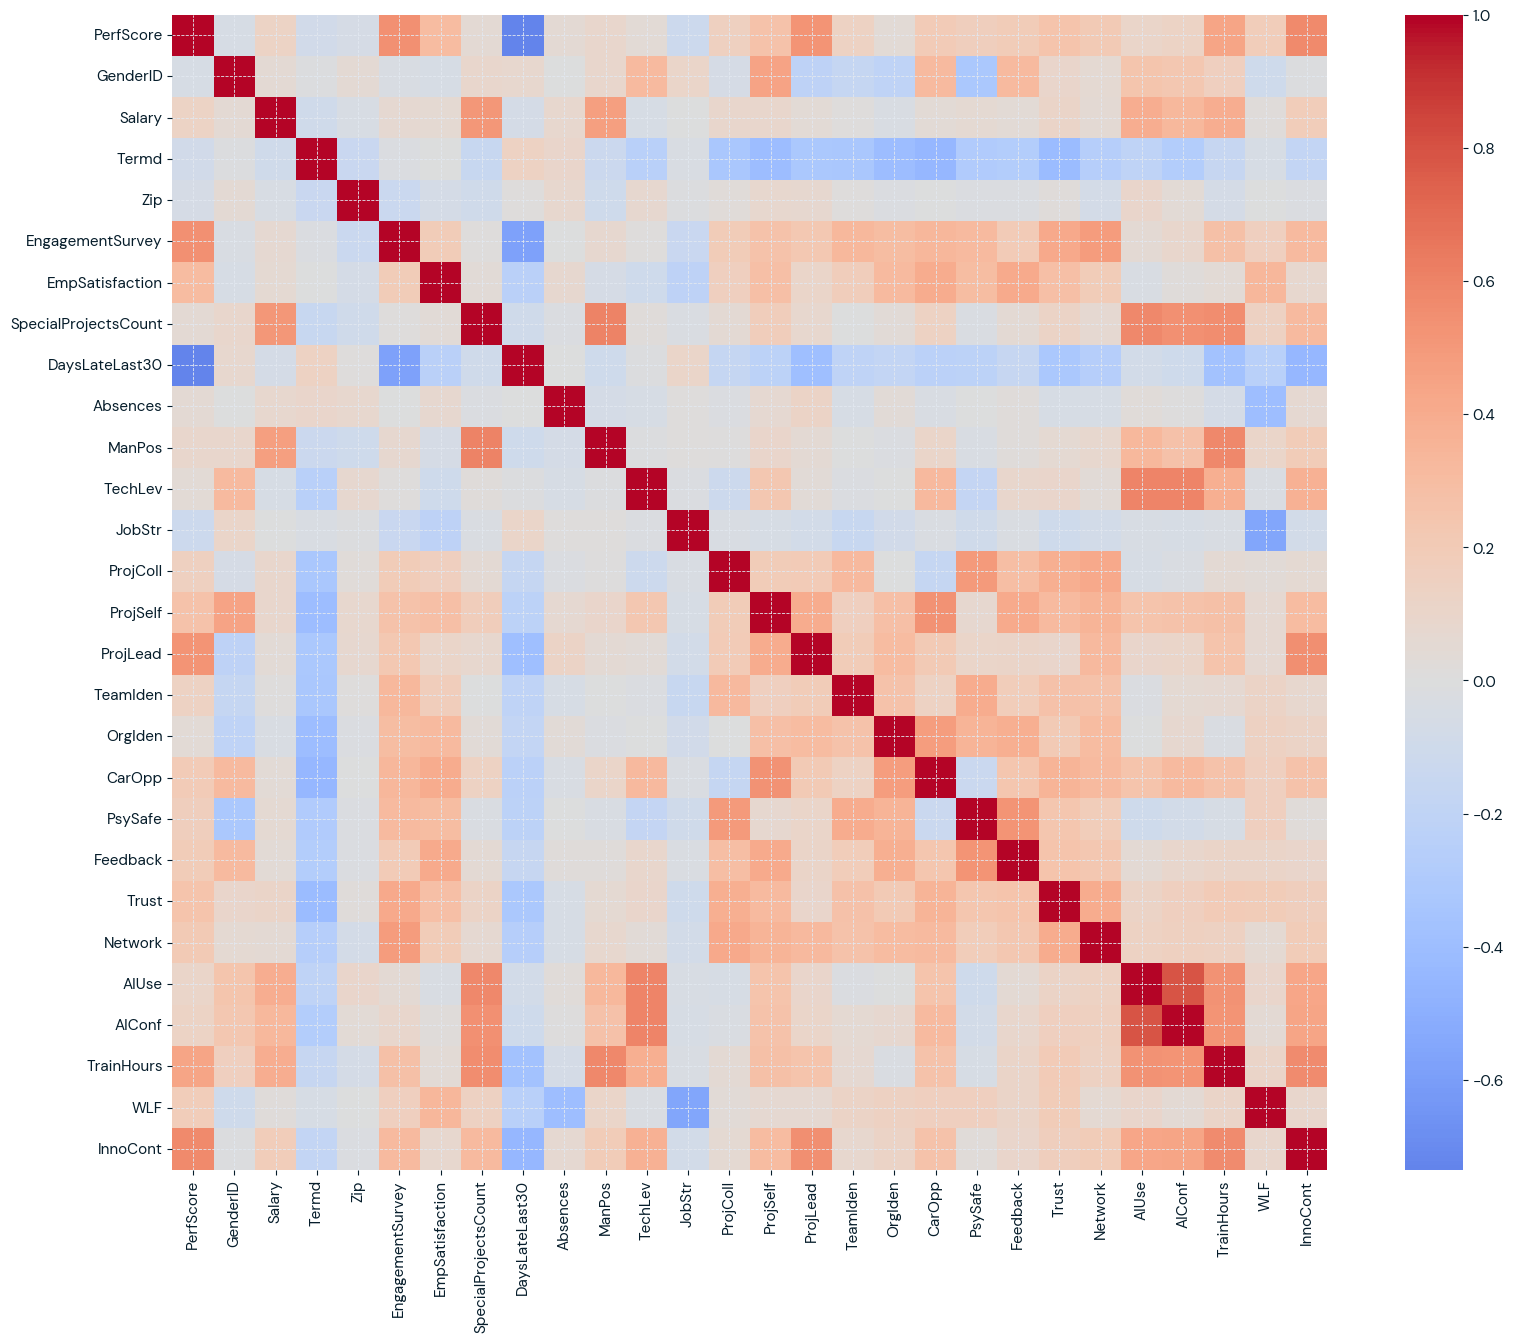

In [8]:
plt.figure(figsize=(20, 15))
numeric_df = df.select_dtypes(include=['number']).drop(columns=['PositionID'], errors='ignore')

sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, square=True)
plt.show()

In [9]:
# isolate target and remove involuntary terminations (Terminated for Cause)
df_model = df[df['EmploymentStatus'] != 'Terminated for Cause'].copy()
df_model['Target_Voluntary_Turnover'] = np.where(
    df_model['EmploymentStatus'] == 'Voluntarily Terminated', 1, 0
)

# time-based feature engineering (Tenure & Age)
df_model['DateofHire'] = pd.to_datetime(df_model['DateofHire'])
df_model['DateofTermination'] = pd.to_datetime(df_model['DateofTermination'])
df_model['DOB'] = pd.to_datetime(df_model['DOB'])

# active employees (NaT in DateofTermination) are anchored to the max date in the dataset to calculate tenure and age consistently
reference_date = df_model['DateofTermination'].max() 
df_model['End_Date'] = df_model['DateofTermination'].fillna(reference_date)

# calculate continuous variables
df_model['Tenure_Months'] = ((df_model['End_Date'] - df_model['DateofHire']).dt.days) / 30.44
df_model['Age'] = ((reference_date - df_model['DOB']).dt.days) / 365.25 

# preserve demographics for Phase 3 Fairness Audit 
# (We save these here so we can test for bias later, but keep them out of the ML pipeline)
df_fairness = df_model[['Employee.Name', 'GenderID', 'RaceDesc', 'Target_Voluntary_Turnover']].copy()

# drop columns that won't be used in the ML model to prevent data leakage and reduce dimensionality 
# #TODO: Could we consider inclusion of Marital Status in th models? #DONE: Not useful
drop_cols = [
    'Termd', 'DateofTermination', 'TermReason',
    'EmploymentStatus', 'PerformanceScore', 'Position', 'Zip', 'State',
    'DateofHire', 'End_Date', 'DOB', 
    'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'GenderID'
]

df_clean = df_model.drop(columns=drop_cols)

#handle remaining missing values (there arent any)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f"Final dataset shape for ML: {df_clean.shape}")
print(df_clean.head())

Final dataset shape for ML: (295, 33)
              Employee.Name  PerfScore  Salary  PositionID         Department  \
0       Adinolfi, Wilson  K          4   62506          19  Production          
1  Ait Sidi, Karthikeyan             3  104437          27              IT/IS   
2         Akinkuolie, Sarah          3   64955          20  Production          
3              Alagbe,Trina          3   64991          19  Production          
4          Anderson, Carol           3   50825          19  Production          

  RecruitmentSource  EngagementSurvey  EmpSatisfaction  SpecialProjectsCount  \
0          LinkedIn              4.60                5                     0   
1            Indeed              4.96                3                     6   
2          LinkedIn              3.02                3                     0   
3            Indeed              4.84                5                     0   
4     Google Search              5.00                4                     

# 2. Feature Engineering + Talent definition

##### Talent definition:

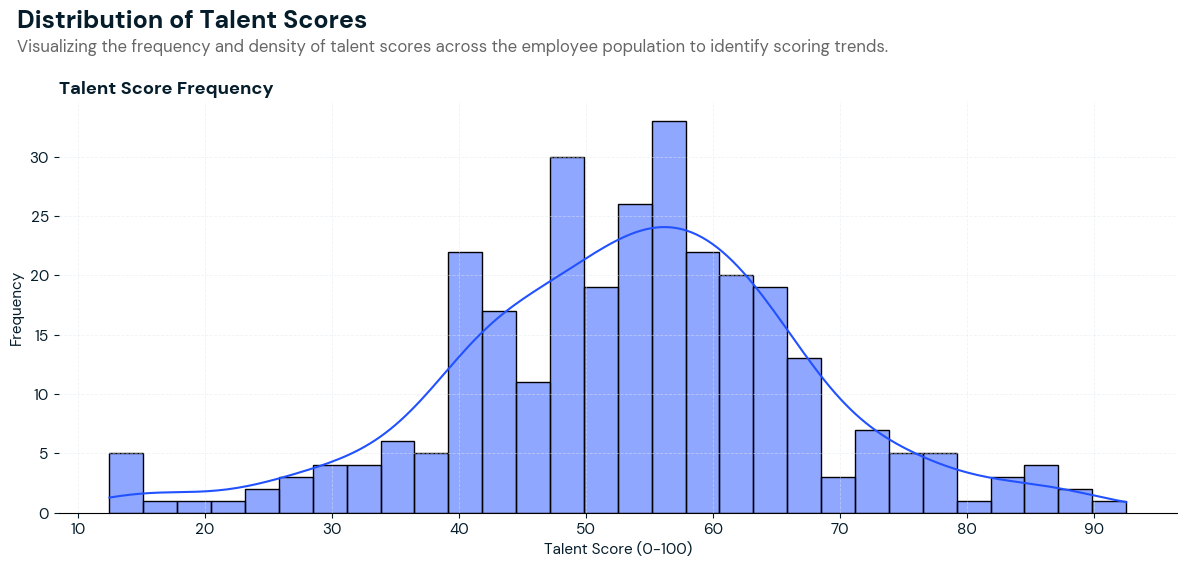

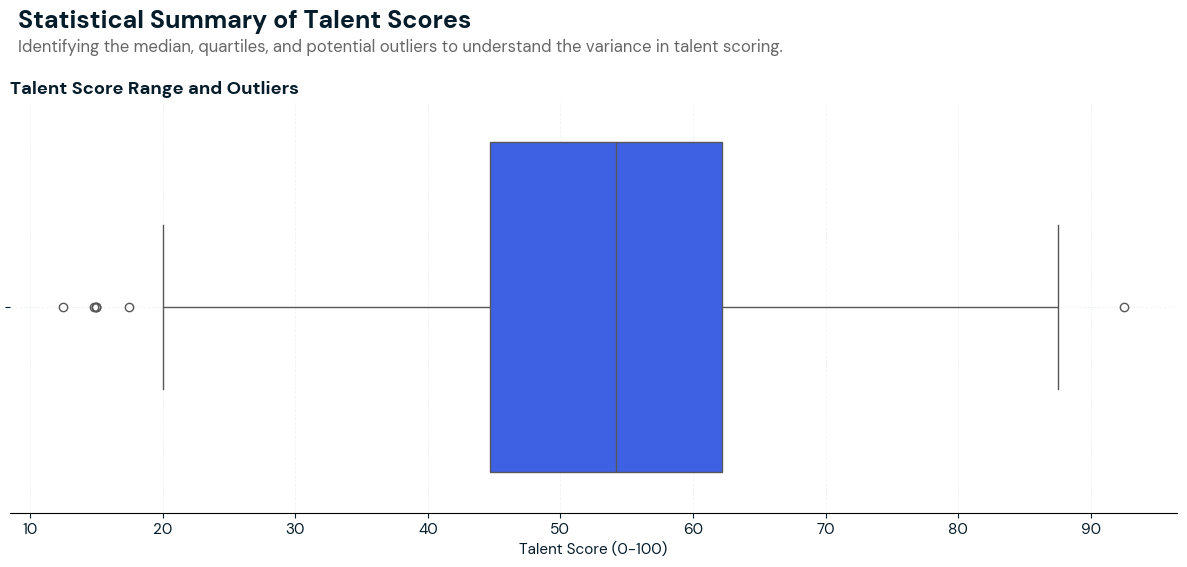

Talent Score Summary Statistics:
count    295.000000
mean      53.565537
std       13.886180
min       12.500000
25%       44.666667
50%       54.166667
75%       62.166667
max       92.500000
Name: TalentScore_100, dtype: float64


In [10]:
scaler = MinMaxScaler()

# create derived variables, kept seperate from talent formula to be used later in unsupervised learning and predictive modeling

#TODO: This is a linear transformation, does it provide anything to the models? #Not really, but we use it in a different model

# A. Performance Gap (Requires scaling first so a 1-4 scale can be subtracted from a 1-5 scale)
scaled_gap_vars = scaler.fit_transform(df_clean[['PerfScore', 'EmpSatisfaction']])
df_clean['Performance_Gap'] = scaled_gap_vars[:, 0] - scaled_gap_vars[:, 1] # Perf minus Satisfaction

# B. Cultural Fit Score 
df_clean['Cultural_Fit_Score'] = df_clean[['TeamIden', 'OrgIden', 'PsySafe']].mean(axis=1)

# C. AI Readiness (Crucial for later segmentation, deliberately left out of Talent Score)
df_clean['AI_Readiness'] = df_clean[['AIUse', 'AIConf']].mean(axis=1)

# D. Work-Life Indicator (Inverting Job Stress so high = good)
df_clean['JobStr_Inverted'] = 6 - df_clean['JobStr']
df_clean['Work_Life_Indicator'] = df_clean[['WLF', 'JobStr_Inverted']].mean(axis=1)
df_clean = df_clean.drop(columns=['JobStr_Inverted']) # Drop the temporary inverted column


#talent column, defined in report
#$$Talent Score = 0.4(0.7 PerfScore + 0.3 ProjLead) + 0.2 InnoCont + 0.2 TechLev + 0.2 ProjColl$$

#talent columns
col_talent = ['PerfScore', 'ProjLead', 'InnoCont', 'TechLev', 'ProjColl']

#standardize because these metrics operate on different scales
std_cols = [f"{col}_std" for col in col_talent]
df_clean[std_cols] = scaler.fit_transform(df_clean[col_talent])

# apply talent formula
df_clean['TalentScore_Scaled'] = (
    0.4 * (0.7 * df_clean['PerfScore_std'] + 0.3 * df_clean['ProjLead_std']) +
    0.2 * df_clean['InnoCont_std'] +
    0.2 * df_clean['TechLev_std'] +
    0.2 * df_clean['ProjColl_std']
)

#convert to 0-100 scale for interpretability
df_clean['TalentScore_100'] = df_clean['TalentScore_Scaled'] * 100


#EDA & Visualizations

# Histogram
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(df_clean['TalentScore_100'], bins=30, kde=True, color=BLUE, ax=ax)

fig.text(0.02, 0.96, "Distribution of Talent Scores", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Visualizing the frequency and density of talent scores across the employee population to identify scoring trends.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Talent Score Frequency', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Talent Score (0-100)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)

ax.grid(True, linestyle='--', alpha=0.5)
talent_threshold = 70
#ax.axvline(talent_threshold, color=ACCENT, linestyle='--', label=f'Selected Threshold: 70')
#ax.legend()

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(x=df_clean['TalentScore_100'], color=BLUE, ax=ax)

fig.text(0.02, 0.96, "Statistical Summary of Talent Scores", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Identifying the median, quartiles, and potential outliers to understand the variance in talent scoring.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Talent Score Range and Outliers', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Talent Score (0-100)', fontsize=11)

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

print("Talent Score Summary Statistics:")
print(df_clean['TalentScore_100'].describe())


We choose 70 as our talent threshold based on the Pareto Principle 80/20 rule (business perspective) and our natural break in the histogram above.

In [11]:
#define top 25% as the talent cutoff
talent_threshold = df_clean['TalentScore_100'].quantile(0.75)
#talent_threshold = 0.7 #(This is an alternative fixed threshold that can be used if you want to set a specific cutoff instead of using the top 25%)

df_clean['Is_Talent'] = np.where(df_clean['TalentScore_100'] >= talent_threshold, 1, 0)

print(f"\nTalent Score Cutoff (Top 25%): {talent_threshold:.2f}")
print(f"Total talents identified (Active & Terminated): {df_clean['Is_Talent'].sum()}")


Talent Score Cutoff (Top 25%): 62.17
Total talents identified (Active & Terminated): 79


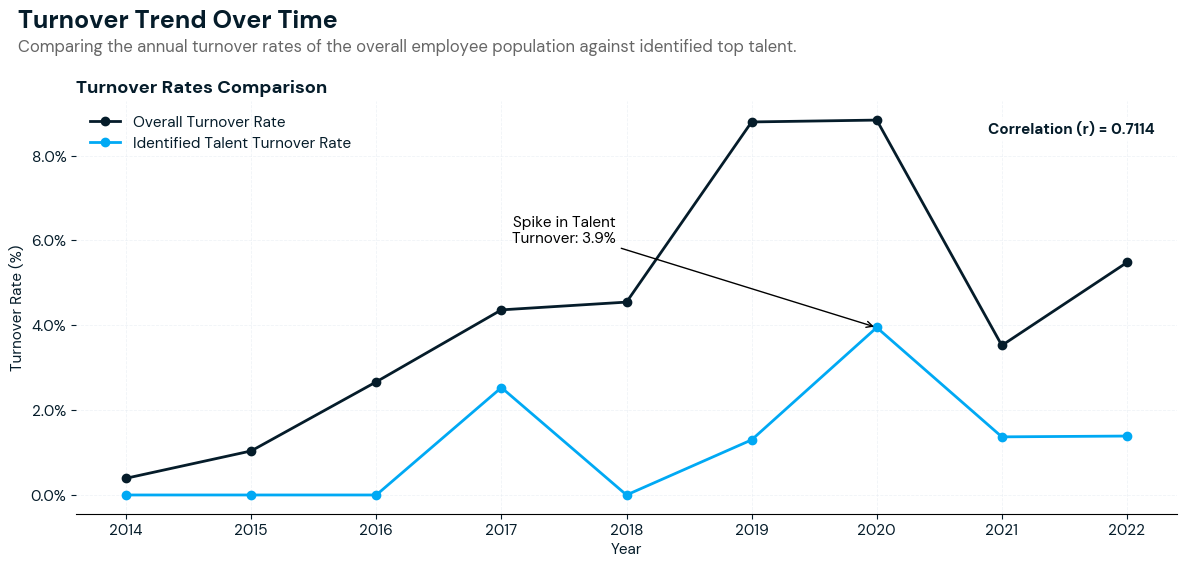

In [12]:
# Bring the 'Is_Talent' flag from df_clean back into the main df for date analysis
df['Is_Talent'] = df_clean['Is_Talent']

#parse dates
df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

df['Hire_Year'] = df['DateofHire'].dt.year
df['Term_Year'] = df['DateofTermination'].dt.year

#calcultae turnover rates by year
min_year = int(df['Hire_Year'].min())
max_year = int(df['Term_Year'].dropna().max())
years = range(min_year, max_year + 1)

trend_data = []
for year in years:
    active_mask = (df['Hire_Year'] <= year) & (df['Term_Year'].isna() | (df['Term_Year'] >= year))
    active_df = df[active_mask]

    term_mask = (df['Term_Year'] == year)
    term_df = df[term_mask]

    total_active = len(active_df)
    total_term = len(term_df)
    overall_rate = (total_term / total_active) if total_active > 0 else 0

    talent_active = len(active_df[active_df['Is_Talent'] == 1])
    talent_term = len(term_df[term_df['Is_Talent'] == 1])
    talent_rate = (talent_term / talent_active) if talent_active > 0 else 0

    if total_active > 0:
        trend_data.append({
            'Year': year,
            'Overall_Turnover_Rate': overall_rate,
            'Talent_Turnover_Rate': talent_rate
        })

trend_df = pd.DataFrame(trend_data)
first_term_year = df['Term_Year'].min()
trend_df = trend_df[trend_df['Year'] >= first_term_year]


#graph
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(trend_df['Year'], trend_df['Overall_Turnover_Rate'], 'o-',
        color=PRIMARY, label="Overall Turnover Rate", linewidth=2)
ax.plot(trend_df['Year'], trend_df['Talent_Turnover_Rate'], 'o-',
        color=BLUE2, label="Identified Talent Turnover Rate", linewidth=2)

ax.set_title("Turnover Rates Comparison", fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Turnover Rate (%)", fontsize=11)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xticks(trend_df['Year'].unique())

ax.legend(frameon=False, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

#annotation for 2020 spike
if 2020 in trend_df['Year'].values:
    yr_2020_data = trend_df[trend_df['Year'] == 2020].iloc[0]
    val_2020 = yr_2020_data['Talent_Turnover_Rate']

    ax.annotate(f"Spike in Talent\nTurnover: {val_2020:.1%}",
                xy=(2020, val_2020),
                xytext=(2017.5, val_2020 + 0.02),
                arrowprops=dict(arrowstyle="->", color='#000'),
                color='#000', fontweight='normal', ha='center')

#correlation score top right
ax.text(0.98, 0.95, "Correlation (r) = 0.7114",
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color=PRIMARY, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

fig.text(0.02, 0.96, "Turnover Trend Over Time",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Comparing the annual turnover rates of the overall employee population against identified top talent.",
         fontsize=12, ha='left', color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])

plt.savefig("my_graph.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. EDA, Statistics, fairness audit

Average Scores: Retained vs. Lost Talent
                     Retained Talent (0)  Lost Talent (1)
Cultural_Fit_Score                  2.97             2.33
Work_Life_Indicator                 3.18             3.06
AI_Readiness                        2.76             3.19
Performance_Gap                     0.04             0.11
TrainHours                         82.72            90.75

--------------------------------------------------

Statistical Proof (T-Tests) for Talent Turnover Drivers:
- Cultural_Fit_Score: p-value = 0.0036 [SIGNIFICANT]
- Work_Life_Indicator: p-value = 0.7789 [Not Significant]
- AI_Readiness: p-value = 0.3217 [Not Significant]
- Performance_Gap: p-value = 0.4583 [Not Significant]
- TrainHours: p-value = 0.3606 [Not Significant]

--------------------------------------------------

Algorithmic Fairness Audit: Testing for Demographic Bias in Talent Formula
Gender: No statistical bias detected (p = 0.6167)
Race/Ethnicity: No statistical bias detected (p = 0.7778)


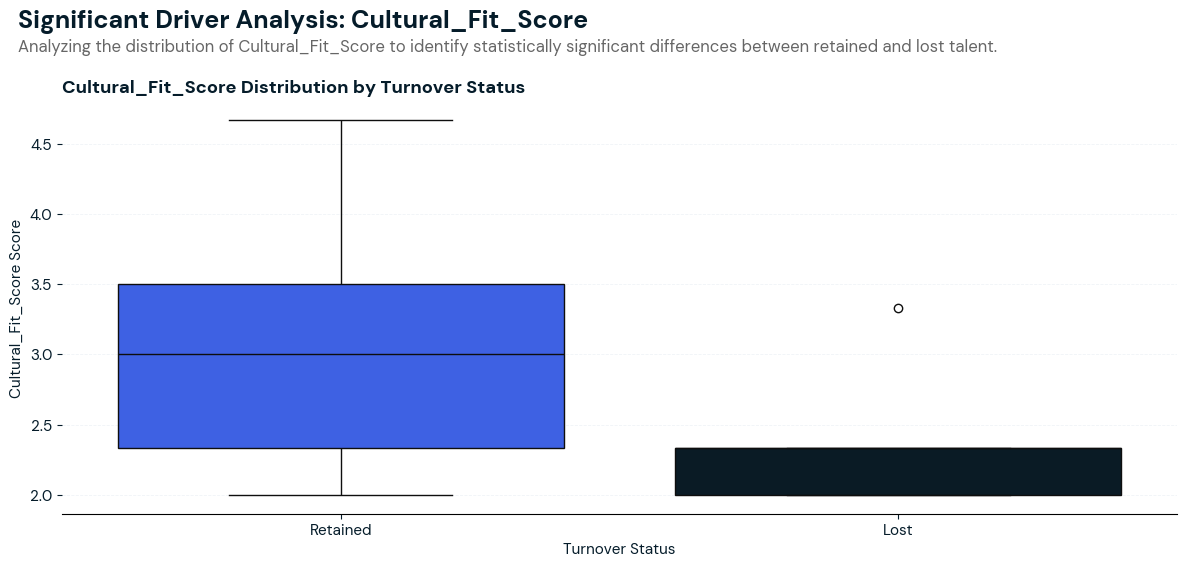

In [13]:
############ drivers of talent turnover: EDA

# filter for ONLY the Talent group
talent_df = df_clean[df_clean['Is_Talent'] == 1].copy()

#select key behavioral and environmental variables to analyze
analysis_vars = ['Cultural_Fit_Score', 'Work_Life_Indicator', 'AI_Readiness', 'Performance_Gap', 'TrainHours']

#calculate means for retained vs. departed talent
talent_means = talent_df.groupby('Target_Voluntary_Turnover')[analysis_vars].mean().T
talent_means.columns = ['Retained Talent (0)', 'Lost Talent (1)']

print("Average Scores: Retained vs. Lost Talent")
print(talent_means.round(2))
print("\n" + "-"*50 + "\n")


######### Statistical Proof of Drivers (T-tests)
#prove it mathematically that these differences are significant and not just random noise. We will run independent T-tests for each variable comparing the retained vs. lost talent groups.

retained = talent_df[talent_df['Target_Voluntary_Turnover'] == 0]
lost = talent_df[talent_df['Target_Voluntary_Turnover'] == 1]

print("Statistical Proof (T-Tests) for Talent Turnover Drivers:")

significant_drivers = []
for var in analysis_vars:
    #t-test
    t_stat, p_val = ttest_ind(retained[var].dropna(), lost[var].dropna(), equal_var=False)
    
    #significance check
    if p_val < 0.05:
        status = "SIGNIFICANT"
        significant_drivers.append(var)
    else:
        status = "Not Significant"
        
    print(f"- {var}: p-value = {p_val:.4f} [{status}]")

print("\n" + "-"*50 + "\n")


####### algorithmic fairness audit

fairness_check = df_fairness.join(df_clean[['TalentScore_100']])

print("Algorithmic Fairness Audit: Testing for Demographic Bias in Talent Formula")

# gender fairness check
# GenderID: 1 = Male, 0 = Female
male_scores = fairness_check[fairness_check['GenderID'] == 1]['TalentScore_100']
female_scores = fairness_check[fairness_check['GenderID'] == 0]['TalentScore_100']

t_stat_gender, p_val_gender = ttest_ind(male_scores.dropna(), female_scores.dropna(), equal_var=False)

if p_val_gender > 0.05:
    print(f"Gender: No statistical bias detected (p = {p_val_gender:.4f})")
else:
    print(f"Gender: Statistical bias detected (p = {p_val_gender:.4f})")

# race fairness check
# Using ANOVA (f_oneway) because RaceDesc has more than 2 categories
race_groups = [group['TalentScore_100'].dropna().values for name, group in fairness_check.groupby('RaceDesc')]
f_stat_race, p_val_race = f_oneway(*race_groups)

if p_val_race > 0.05:
    print(f"Race/Ethnicity: No statistical bias detected (p = {p_val_race:.4f})")
else:
    print(f"Race/Ethnicity: Statistical bias detected (p = {p_val_race:.4f})")

######## visualization of the most significant driver
# pick most significant driver (lowest p-value) to visualize the difference between retained vs. lost talent groups

if significant_drivers:
    top_driver = significant_drivers[0]
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.boxplot(
        data=talent_df, 
        x='Target_Voluntary_Turnover', 
        y=top_driver,
        hue='Target_Voluntary_Turnover', 
        palette=[BLUE, ACCENT],
        ax=ax
    )

    fig.text(0.02, 0.96, f"Significant Driver Analysis: {top_driver}", 
             fontsize=18, fontweight='700', ha='left', color=PRIMARY)
    fig.text(0.02, 0.92, f"Analyzing the distribution of {top_driver} to identify statistically significant differences between retained and lost talent.", 
             fontsize=12, ha='left', color='#666666')

    ax.set_title(f'{top_driver} Distribution by Turnover Status', fontweight='bold', loc='left', color=PRIMARY)
    ax.set_xlabel('Turnover Status', fontsize=11)
    ax.set_ylabel(f'{top_driver} Score', fontsize=11)
    ax.set_xticks(ticks=[0, 1])
    ax.set_xticklabels(['Retained', 'Lost'])

    ax.legend().set_visible(False)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.05, 1, 0.90])
    plt.savefig('styled_driver_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

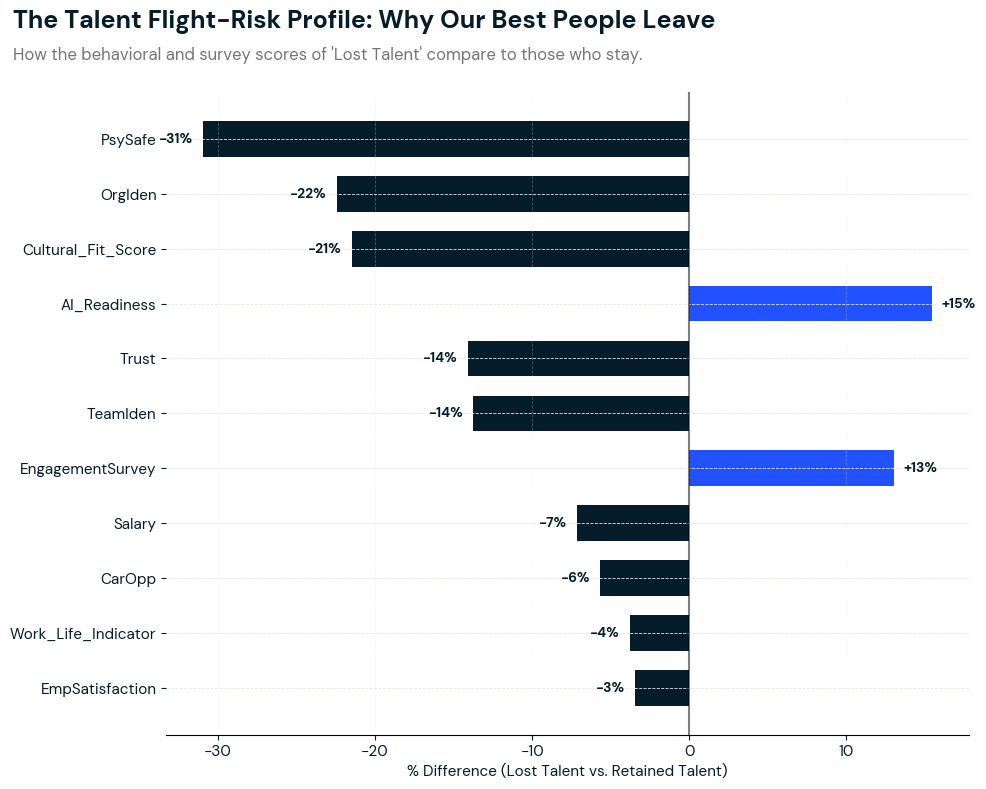

In [14]:
#############################################################################################################
# FEATURE IMPORTANCE & DRIVER GAP ANALYSIS
#############################################################################################################

#isolate top talent
talent_df = df_clean[df_clean['Is_Talent'] == 1].copy()
df_lost = talent_df[talent_df['Target_Voluntary_Turnover'] == 1]
df_retained = talent_df[talent_df['Target_Voluntary_Turnover'] == 0]

# select the same columns we analyzed before, but we can expand this to include more variables if desired 
compare_cols = [
    'CarOpp', 'EngagementSurvey', 'PsySafe', 'Trust', 'EmpSatisfaction', 
    'Cultural_Fit_Score', 'Work_Life_Indicator', 'TeamIden', 'OrgIden', 'AI_Readiness', 'Salary'
]

#Calculate % Difference: (Lost - Retained) / Retained * 100
diff_pct = (df_lost[compare_cols].mean() - df_retained[compare_cols].mean()) / df_retained[compare_cols].mean() * 100

#sort by absolute value for a clean "tornado" plot
top_sorted = diff_pct.reindex(diff_pct.abs().sort_values(ascending=True).index)

#plot
fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = np.where(top_sorted < 0, ACCENT, BLUE)
bars = ax.barh(top_sorted.index, top_sorted.values, color=bar_colors, height=0.65)

ax.set_xlabel("% Difference (Lost Talent vs. Retained Talent)", fontsize=11, color=PRIMARY)
ax.axvline(0, color='black', linewidth=1.5, alpha=0.5)
ax.grid(axis='x', linestyle='--', alpha=0.3)

max_val = top_sorted.abs().max()
offset = max_val * 0.02 

for bar in bars:
    width = bar.get_width()
    label_text = f"{width:+.0f}%"

    if width < 0:
        x_pos = width - offset
        alignment = 'right'
    else:
        x_pos = width + offset
        alignment = 'left'

    ax.text(x_pos, bar.get_y() + bar.get_height()/2, label_text,
            va='center', ha=alignment, fontsize=10, color=PRIMARY, fontweight='bold')

fig.text(0.02, 0.96, "The Talent Flight-Risk Profile: Why Our Best People Leave",
         fontsize=18, fontweight='bold', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "How the behavioral and survey scores of 'Lost Talent' compare to those who stay.",
         fontsize=12, ha='left', color=GRAY)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('behavioral_gap.png', dpi=300)
plt.show()

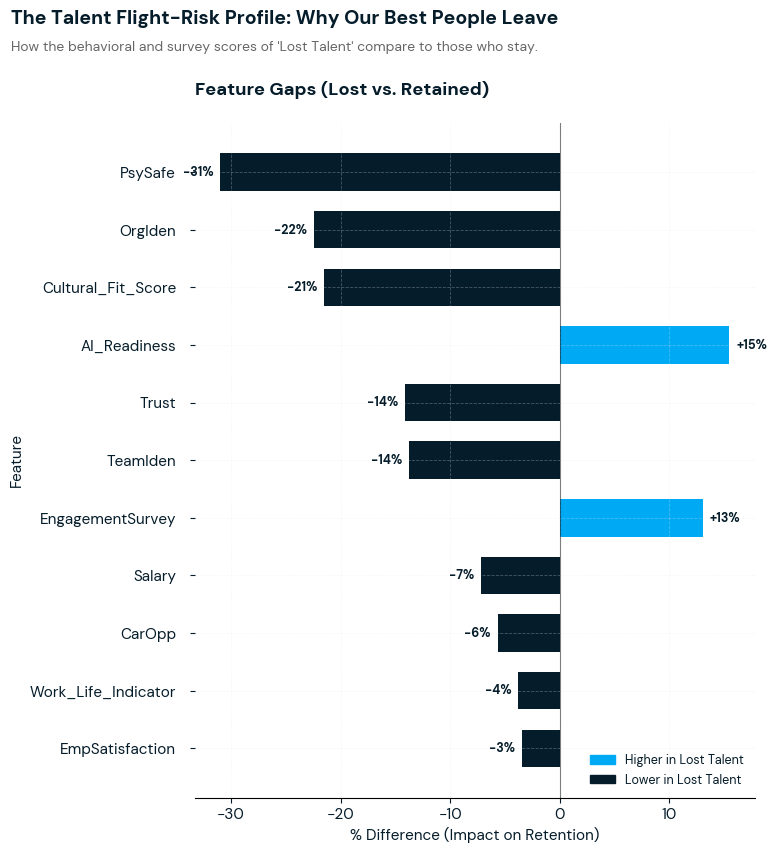

In [15]:
#############################################################################################################
# FEATURE IMPORTANCE & DRIVER GAP ANALYSIS (Updated Aspect Ratio)
#############################################################################################################

# Isolate top talent
talent_df = df_clean[df_clean['Is_Talent'] == 1].copy()
df_lost = talent_df[talent_df['Target_Voluntary_Turnover'] == 1]
df_retained = talent_df[talent_df['Target_Voluntary_Turnover'] == 0]

# Select columns
compare_cols = [
    'CarOpp', 'EngagementSurvey', 'PsySafe', 'Trust', 'EmpSatisfaction', 
    'Cultural_Fit_Score', 'Work_Life_Indicator', 'TeamIden', 'OrgIden', 'AI_Readiness', 'Salary'
]

# Calculate % Difference
diff_pct = (df_lost[compare_cols].mean() - df_retained[compare_cols].mean()) / df_retained[compare_cols].mean() * 100

# Sort by absolute value for a clean "tornado" plot
top_sorted = diff_pct.reindex(diff_pct.abs().sort_values(ascending=True).index)

# Updated figsize to match the ~8:9 aspect ratio
fig, ax = plt.subplots(figsize=(8, 9)) 

bar_colors = np.where(top_sorted < 0, ACCENT, BLUE2)
bars = ax.barh(top_sorted.index, top_sorted.values, color=bar_colors, edgecolor='none', height=0.65)

# 1. ADD PADDING TO Y-AXIS LABELS
# This pushes the text "PsySafe", "OrgIden", etc., further to the left of the axis line
ax.tick_params(axis='y', pad=10) 

# 2. MANUALLY ADJUST SUBPLOT MARGINS
# 'left=0.25' ensures 25% of the figure width is reserved for the labels
plt.subplots_adjust(left=0.25, right=0.95, top=0.85, bottom=0.1)

# Scaled down fontsize slightly to fit the narrower figure width
fig.text(0.02, 0.96, "The Talent Flight-Risk Profile: Why Our Best People Leave",
         fontsize=14, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.93, "How the behavioral and survey scores of 'Lost Talent' compare to those who stay.",
         fontsize=10, ha='left', color='#666666')

# Formatting axes
ax.set_title('Feature Gaps (Lost vs. Retained)', fontweight='bold', loc='left', color=PRIMARY, pad=20)
ax.set_xlabel('% Difference (Impact on Retention)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax.grid(True, linestyle='--', alpha=0.3)

# Add data labels (the +/- % text)
max_val = top_sorted.abs().max()
offset = max_val * 0.02 

for bar in bars:
    width = bar.get_width()
    label_text = f"{width:+.0f}%"
    
    if width < 0:
        x_pos = width - offset
        alignment = 'right'
    else:
        x_pos = width + offset
        alignment = 'left'

    ax.text(x_pos, bar.get_y() + bar.get_height()/2, label_text,
            va='center', ha=alignment, fontsize=9, color=PRIMARY, fontweight='bold')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Optional: remove left spine for a cleaner look

# Legend
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=BLUE2, label='Higher in Lost Talent'),
    plt.Rectangle((0,0),1,1, color=ACCENT, label='Lower in Lost Talent')
], frameon=False, loc='lower right', fontsize=9)

# Use bbox_inches='tight' during save to ensure no labels are cut off
plt.savefig("Behavioral Gap Analysis vertical.svg", format='svg', bbox_inches='tight')
plt.show()

--- Departmental Validation of Turnover & Drivers (Talent Pool) ---

1. Talent Turnover Rate by Department (%):
Department
Software Engineering    25.0
Production              12.5
IT/IS                    5.0
Admin Offices            0.0
Sales                    0.0
Name: Target_Voluntary_Turnover, dtype: float64

2. Cultural Fit Score Gap by Department:
                      Retained (0)  Lost (1)  Difference
Department                                              
Admin Offices                 2.83       NaN         NaN
IT/IS                         2.98      2.00        0.98
Production                    2.98      2.39        0.60
Sales                         2.60       NaN         NaN
Software Engineering          3.44      2.33        1.11


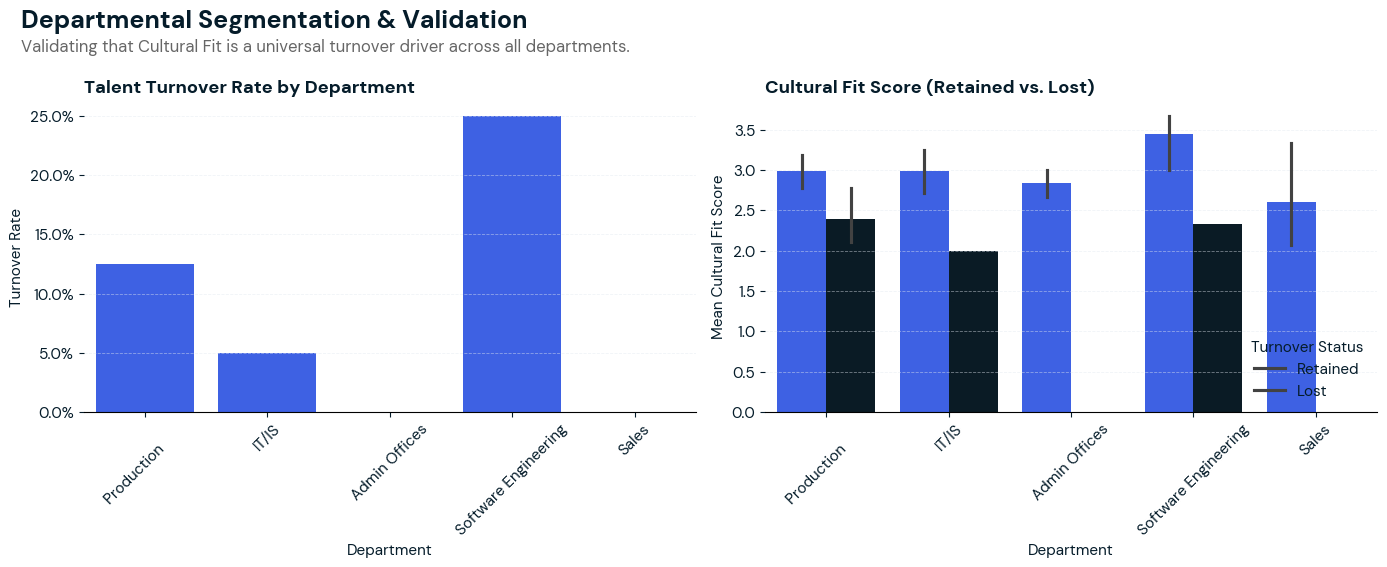

In [19]:
#############################################################################################################
# SEGMENTATION & VALIDATION: DEPARTMENT LEVEL ANALYSIS
#############################################################################################################

# We use the talent_df created earlier to focus specifically on top talent turnover
print("--- Departmental Validation of Turnover & Drivers (Talent Pool) ---")

# 1. Talent Turnover Rate by Department
dept_turnover = talent_df.groupby('Department')['Target_Voluntary_Turnover'].mean() * 100
print("\n1. Talent Turnover Rate by Department (%):")
print(dept_turnover.sort_values(ascending=False).round(1))

# 2. Cultural Fit Score Validation Across Departments
dept_cultural_fit = talent_df.groupby(['Department', 'Target_Voluntary_Turnover'])['Cultural_Fit_Score'].mean().unstack()
dept_cultural_fit.columns = ['Retained (0)', 'Lost (1)']
dept_cultural_fit['Difference'] = dept_cultural_fit['Retained (0)'] - dept_cultural_fit['Lost (1)']
print("\n2. Cultural Fit Score Gap by Department:")
print(dept_cultural_fit.round(2))

# 3. Visualization matching the notebook's aesthetic
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Turnover Rate
sns.barplot(
    data=talent_df,
    x='Department',
    y='Target_Voluntary_Turnover',
    errorbar=None,
    color=BLUE,
    ax=axes[0]
)
axes[0].set_title('Talent Turnover Rate by Department', fontweight='bold', loc='left', color=PRIMARY)
axes[0].set_ylabel('Turnover Rate', fontsize=11)
axes[0].set_xlabel('Department', fontsize=11)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Plot 2: Cultural Fit Gap
sns.barplot(
    data=talent_df,
    x='Department',
    y='Cultural_Fit_Score',
    hue='Target_Voluntary_Turnover',
    palette=[BLUE, ACCENT],
    ax=axes[1]
)
axes[1].set_title('Cultural Fit Score (Retained vs. Lost)', fontweight='bold', loc='left', color=PRIMARY)
axes[1].set_ylabel('Mean Cultural Fit Score', fontsize=11)
axes[1].set_xlabel('Department', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Turnover Status', labels=['Retained', 'Lost'], frameon=False)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Apply custom titles matching previous graphs
fig.text(0.02, 0.96, "Departmental Segmentation & Validation",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Validating that Cultural Fit is a universal turnover driver across all departments.",
         fontsize=12, ha='left', color='#666666')

# Clean up spines
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('departmental_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Unsupervised Learning

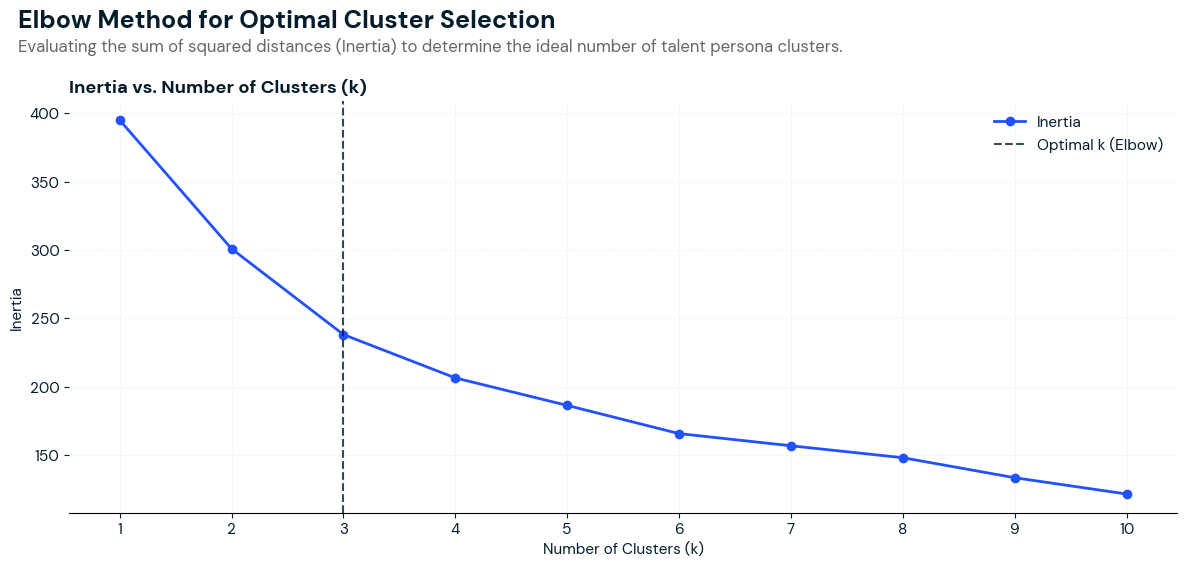

Talent Persona Segmentation (Cluster Profiles):
Persona_Cluster        0      1      2
Avg_Cultural_Fit    2.58   2.75   3.49
Avg_Work_Life       2.75   2.97   3.93
Avg_AI_Readiness    3.85   2.16   2.98
Avg_TrainHours    113.15  72.29  75.67
Avg_Perf_Gap        0.11   0.18  -0.23
Turnover_Rate      20.0%   8.0%   5.0%
Headcount             20     38     21

------------------------------------------------------------



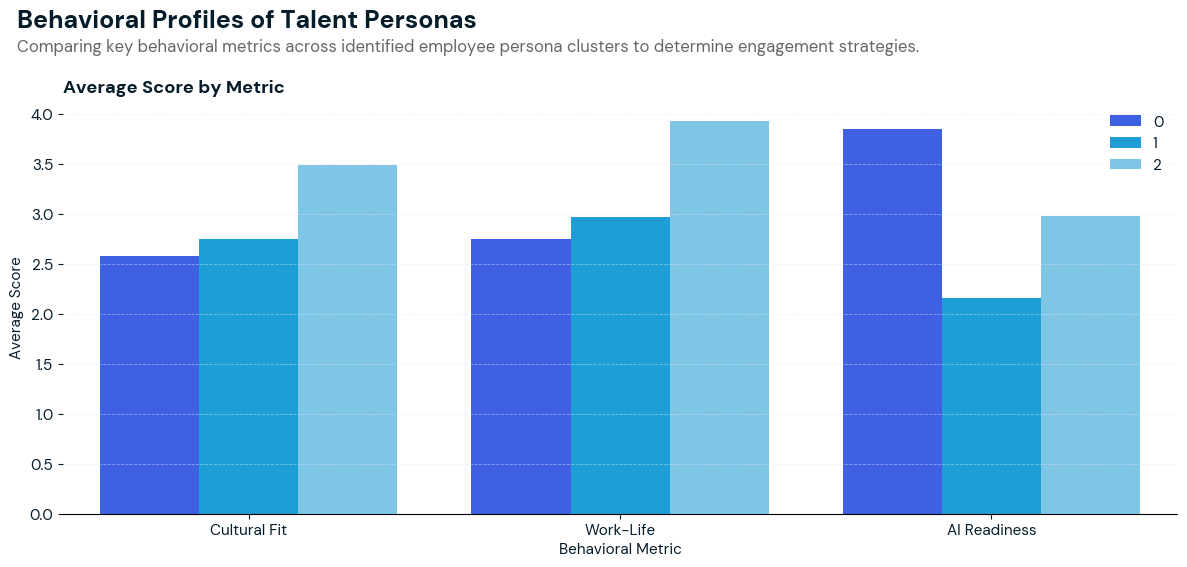

In [16]:
#############################################################################################################
# CLUSTERING ANALYSIS
#############################################################################################################

# prep data
talent_df = df_clean[df_clean['Is_Talent'] == 1].copy()

# select the derived variables for clustering
cluster_features = [
    'Cultural_Fit_Score', 
    'Work_Life_Indicator', 
    'AI_Readiness', 
    'TrainHours',
    'Performance_Gap'
]

#k-means is sensitive to scale, so we standardize the features first
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(talent_df[cluster_features])

#inertia
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_cluster)
    inertias.append(kmeans_test.inertia_)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(k_range, inertias, 'o-', color=BLUE, linewidth=2, label="Inertia")

fig.text(0.02, 0.96, "Elbow Method for Optimal Cluster Selection", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Evaluating the sum of squared distances (Inertia) to determine the ideal number of talent persona clusters.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Inertia vs. Number of Clusters (k)', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)

ax.set_xticks(k_range)
ax.grid(True, linestyle='--', alpha=0.5)

ax.axvline(x=3, color=ACCENT, linestyle='--', alpha=0.8, label='Optimal k (Elbow)')
ax.legend(frameon=False, loc='upper right')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('styled_elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = 3 

#fit kmeans with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
talent_df['Persona_Cluster'] = kmeans.fit_predict(X_cluster)


#cluster profiling and visualization
cluster_profiling = talent_df.groupby('Persona_Cluster').agg({
    'Cultural_Fit_Score': 'mean',
    'Work_Life_Indicator': 'mean',
    'AI_Readiness': 'mean',
    'TrainHours': 'mean',
    'Performance_Gap': 'mean',
    'Target_Voluntary_Turnover': ['mean', 'count'] # 'mean' gives the turnover rate, 'count' gives group size
}).round(2)

#flatten multi-level columns for easier reading
cluster_profiling.columns = [
    'Avg_Cultural_Fit', 'Avg_Work_Life', 'Avg_AI_Readiness', 
    'Avg_TrainHours', 'Avg_Perf_Gap', 'Turnover_Rate', 'Headcount'
]

#convert turnover rate to percentage format for better readability
cluster_profiling['Turnover_Rate'] = (cluster_profiling['Turnover_Rate'] * 100).astype(str) + '%'

print("Talent Persona Segmentation (Cluster Profiles):")
print(cluster_profiling.T)
print("\n" + "-"*60 + "\n")

#visualize the behavioral profiles of the clusters using a grouped bar chart
plot_features = ['Avg_Cultural_Fit', 'Avg_Work_Life', 'Avg_AI_Readiness']
cluster_plot_df = cluster_profiling[plot_features].reset_index()
melted_df = cluster_plot_df.melt(id_vars='Persona_Cluster', var_name='Metric', value_name='Average Score')



fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=melted_df, 
    x='Metric', 
    y='Average Score', 
    hue='Persona_Cluster', 
    palette=[BLUE, BLUE2, BLUE3],
    ax=ax
)

fig.text(0.02, 0.96, "Behavioral Profiles of Talent Personas", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Comparing key behavioral metrics across identified employee persona clusters to determine engagement strategies.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Average Score by Metric', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Behavioral Metric', fontsize=11)
ax.set_ylabel('Average Score', fontsize=11)

ax.set_xticks(ticks=[0, 1, 2])
ax.set_xticklabels(['Cultural Fit', 'Work-Life', 'AI Readiness'])

ax.legend(frameon=False, loc='upper right', title=None)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('styled_persona_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

# NOTE FOR REPORT: You will look at the output above and give them human names.
# For example, if Cluster 0 has high TrainHours & AI_Readiness but low Work_Life, 
# you name them the "Burned-Out Innovators".

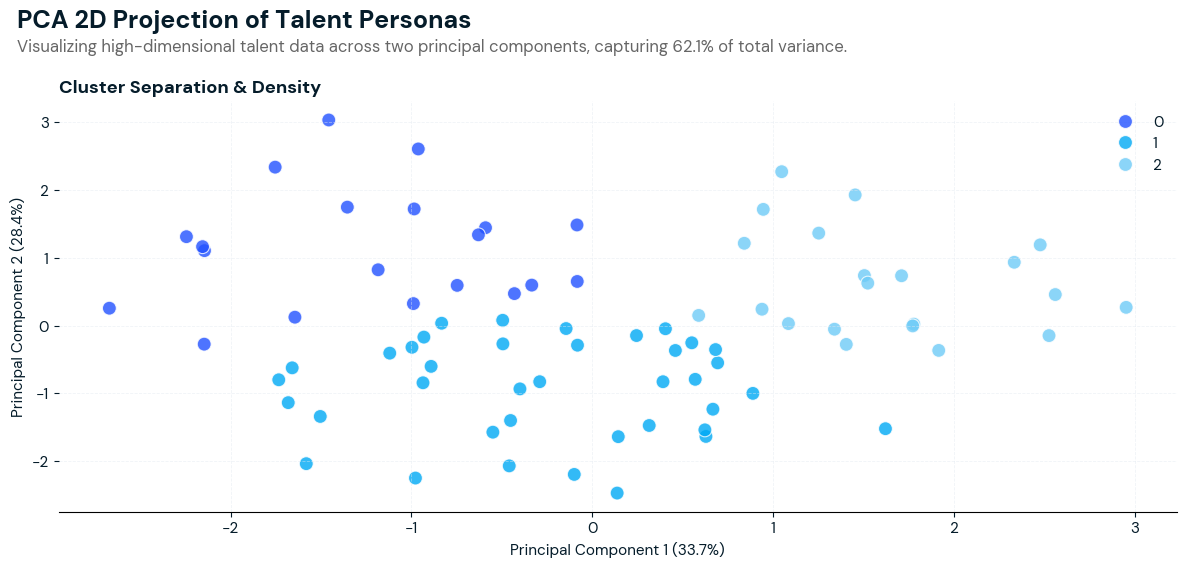

In [17]:
#PCA

#create the cluster column first to avoid errors in the PCA plotting code
optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
talent_df['Persona_Cluster'] = kmeans.fit_predict(X_cluster)

#compress the 5-dimensional cluster data down to 2 dimensions for visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

#add the PCA components back to the dataframe for plotting
talent_df['PCA1'] = X_pca[:, 0]
talent_df['PCA2'] = X_pca[:, 1]

#variance explained by the 2 principal components (for axis labels)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=talent_df, 
    x='PCA1', 
    y='PCA2', 
    hue='Persona_Cluster', 
    palette=[BLUE, BLUE2, BLUE3], 
    s=100,        
    alpha=0.8,
    ax=ax
)

fig.text(0.02, 0.96, "PCA 2D Projection of Talent Personas", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, f"Visualizing high-dimensional talent data across two principal components, capturing {var_explained[0]+var_explained[1]:.1f}% of total variance.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Cluster Separation & Density', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel(f'Principal Component 1 ({var_explained[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'Principal Component 2 ({var_explained[1]:.1f}%)', fontsize=11)

ax.legend(frameon=False, loc='upper right', title=None)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('styled_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Supervised Learning

We will use a combination of classic and SOTE models, along with 2 forms of scaling to see which model shows the best performance.

We optimize for recall because failing to identify a top talent who is actively preparing to leave (a false negative) is the most expensive operational error for the company. It is far better to accidentally offer a retention intervention to a loyal employee than to let a hidden flight risk walk out the door unnoticed.

In [ ]:
df_clean.shape

(295, 45)

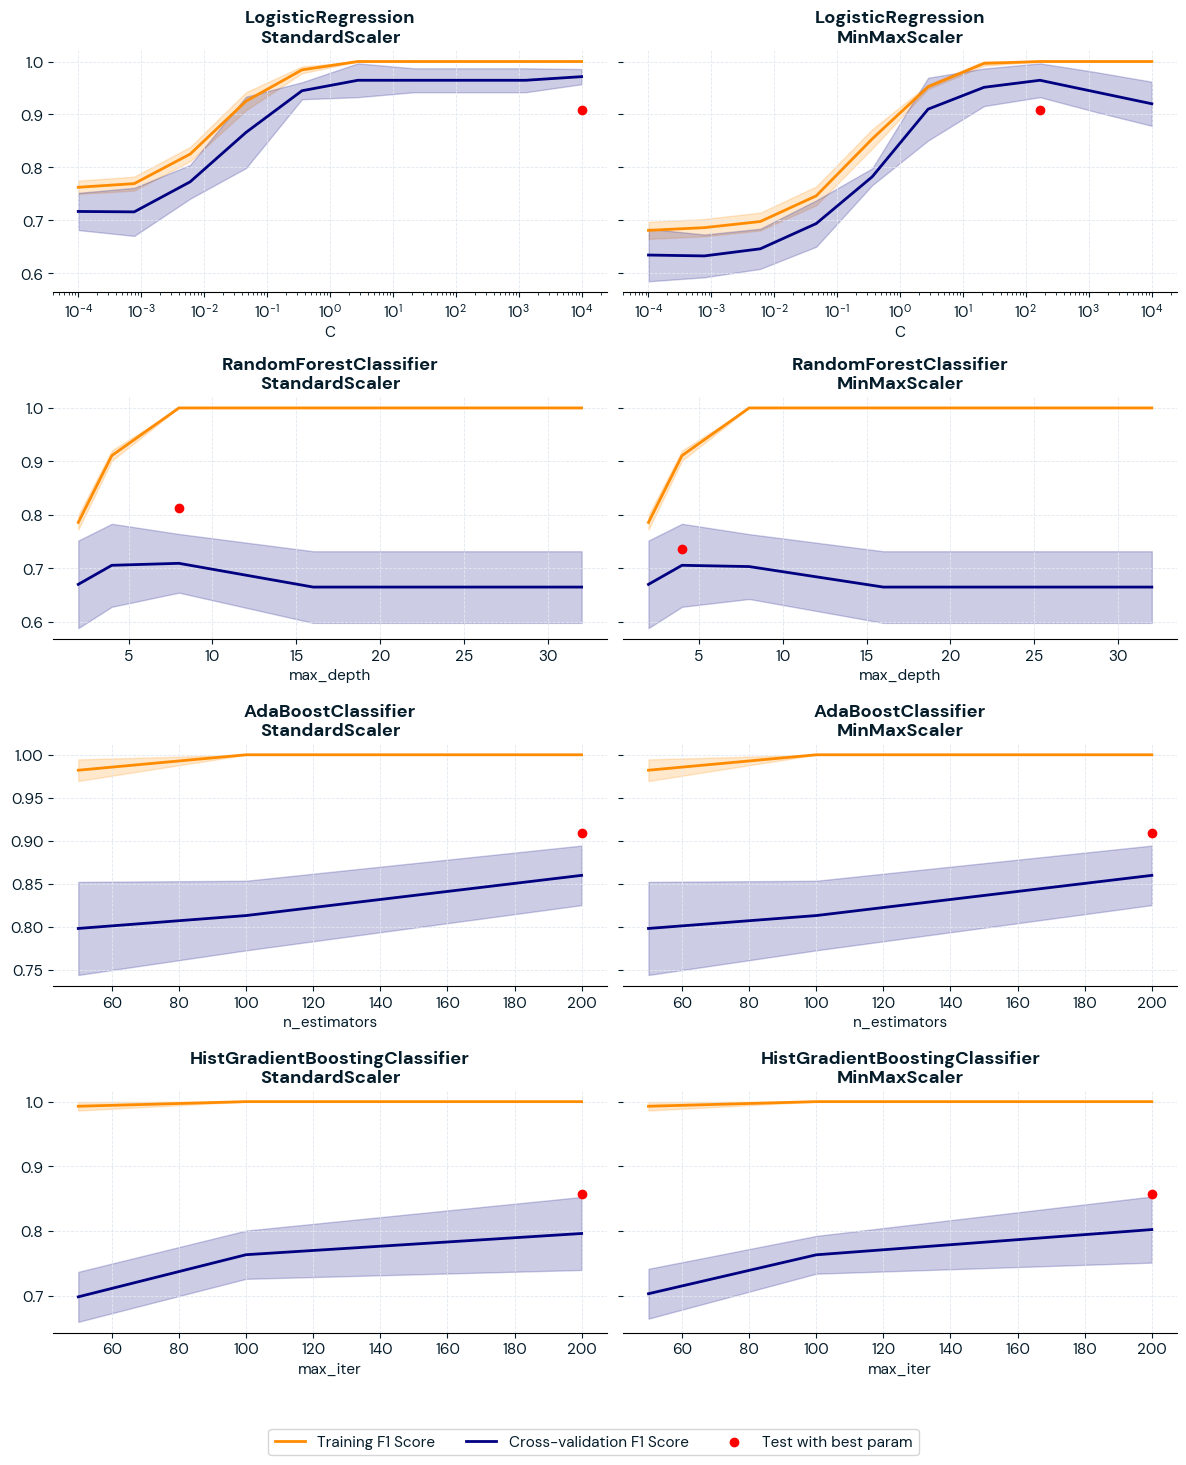


--- Summary Table (Sorted by F1 Score) ---
                                               accuracy  precision    recall  \
LogisticRegression             StandardScaler  0.949153   1.000000  0.833333   
                               MinMaxScaler    0.949153   1.000000  0.833333   
RandomForestClassifier         StandardScaler  0.898305   0.928571  0.722222   
                               MinMaxScaler    0.830508   0.700000  0.777778   
AdaBoostClassifier             StandardScaler  0.949153   1.000000  0.833333   
                               MinMaxScaler    0.949153   1.000000  0.833333   
HistGradientBoostingClassifier StandardScaler  0.915254   0.882353  0.833333   
                               MinMaxScaler    0.915254   0.882353  0.833333   

                                                     f1  
LogisticRegression             StandardScaler  0.909091  
                               MinMaxScaler    0.909091  
RandomForestClassifier         StandardScaler  0.812500  
   

In [ ]:

num_features = [ 
    'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
    'DaysLateLast30', 'Absences', 'TechLev', 'TrainHours', 'InnoCont',
    'CarOpp', 'PsySafe', 'Trust', 'TeamIden', 'OrgIden',
    'Cultural_Fit_Score', 'AI_Readiness', 
    'Work_Life_Indicator', 'Performance_Gap', 'TalentScore_100'
]
cat_features = ['Department', 'RecruitmentSource','Remote']

X = df_clean[num_features + cat_features]
y = df_clean['Target_Voluntary_Turnover']

#encode categorical variables using one-hot encoding, dropping the first category to avoid multicollinearity
# TODO: Also might be better practice to choose which col to drop, instead of just the first col. 
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y) 
#TODO:Theoretically this line might have to come way earlier. 

def compute_classification_metrics(y_true, y_pred,best_param): #TODO: Here is where we can try building a new loss function
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }

############################################################################################################
# SETUP
############################################################################################################

scalers = [StandardScaler, MinMaxScaler] #Based on data we have, maybe a min-max scaler is sufficient. Most features bounded. 
models = [
    (LogisticRegression, 'estimator__C', np.logspace(-4, 4, 10)),
    (RandomForestClassifier, 'estimator__max_depth', [2, 4, 8, 16, 32]), #TODO: Maybe n_samples gives better results
    (AdaBoostClassifier, 'estimator__n_estimators', [50, 100, 200]),
    (HistGradientBoostingClassifier, 'estimator__max_iter', [50, 100, 200])
]

############################################################################################################
# CALCULATING & VISUALIZATION
############################################################################################################

ncols, nrows = len(scalers), len(models)
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 3.5 * nrows), tight_layout=True, sharey='row')
axs = axs.ravel()

results = {}
best_overall_model = None  #save the best model for later SHAP analysis and ROI simulation
best_recall = 0

for row, (estimator_cls, param_name, param_range) in enumerate(models):
    for col, scaler_cls in enumerate(scalers):
        ax = axs[row * ncols + col]

        # Initialize models (added balanced weights for HR data imbalance) # TODO: We can maybe also consider other techniques. 
        if estimator_cls == LogisticRegression:
            model = estimator_cls(max_iter=2000, random_state=42, class_weight='balanced')
        elif estimator_cls == RandomForestClassifier:
            model = estimator_cls(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
        elif estimator_cls == AdaBoostClassifier:
            model = estimator_cls(random_state=42)
        elif estimator_cls == HistGradientBoostingClassifier:
            model = estimator_cls(random_state=42)

        # Pipeline
        pipe = Pipeline([
            ('scaler', scaler_cls()),
            ('estimator', model),
        ])

        # Grid search w/ CV=5 using RECALL
        # employing recall as the primary metric to prioritize identifying at-risk talent, which is crucial for retention strategies
        grid = GridSearchCV(pipe, {param_name: param_range}, return_train_score=True, cv=5, scoring='f1', n_jobs=-1)

        grid.fit(X_train, y_train)

        best_estimator = grid.best_estimator_
        best_param_value = grid.best_params_[param_name]

        # calculate recall on the test set using the best estimator from the grid search
        y_test_pred = best_estimator.predict(X_test)
        y_test_recall = recall_score(y_test, y_test_pred)

        # track best model for SHAP/ROI steps later
        if y_test_recall > best_recall:
            best_recall = y_test_recall
            best_overall_model = best_estimator

        # calculate test score
        y_test_score = grid.score(X_test, y_test)

        # cv results for plotting
        res = grid.cv_results_
        train_mean = res['mean_train_score']
        train_std = res['std_train_score']
        test_mean = res['mean_test_score']
        test_std = res['std_test_score']

        # training and validation curves
        ax.plot(param_range, train_mean, label="Training F1 Score", color="darkorange", lw=2)
        ax.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")

        ax.plot(param_range, test_mean, label="Cross-validation F1 Score", color="navy", lw=2)
        ax.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

        # test point
        ax.scatter(best_param_value, y_test_score, color='red', label='Test with best param', zorder=5)

        # metrics
        metrics = compute_classification_metrics(y_test, best_estimator.predict(X_test),best_param_value)
        results[(estimator_cls.__name__, scaler_cls.__name__)] = metrics

        #formatting
        ax.set_title(f'{estimator_cls.__name__}\n{scaler_cls.__name__}')
        ax.set_xlabel(param_name.split('__')[1])
        if 'C' in param_name: ax.set_xscale('log')
        if col != 0: ax.set_ylabel('')

# legend
handles, labels = axs[0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
fig.legend(unique_labels.values(), unique_labels.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3)

plt.show()

# summary (sorted by recall since that was our primary metric for model selection)
# results_df = pd.DataFrame(results).T.sort_values(by='recall', ascending=False)
results_df = pd.DataFrame(results).T
print("\n--- Summary Table (Sorted by F1 Score) ---")
print(results_df)



c:\Users\Kéan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\Kéan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


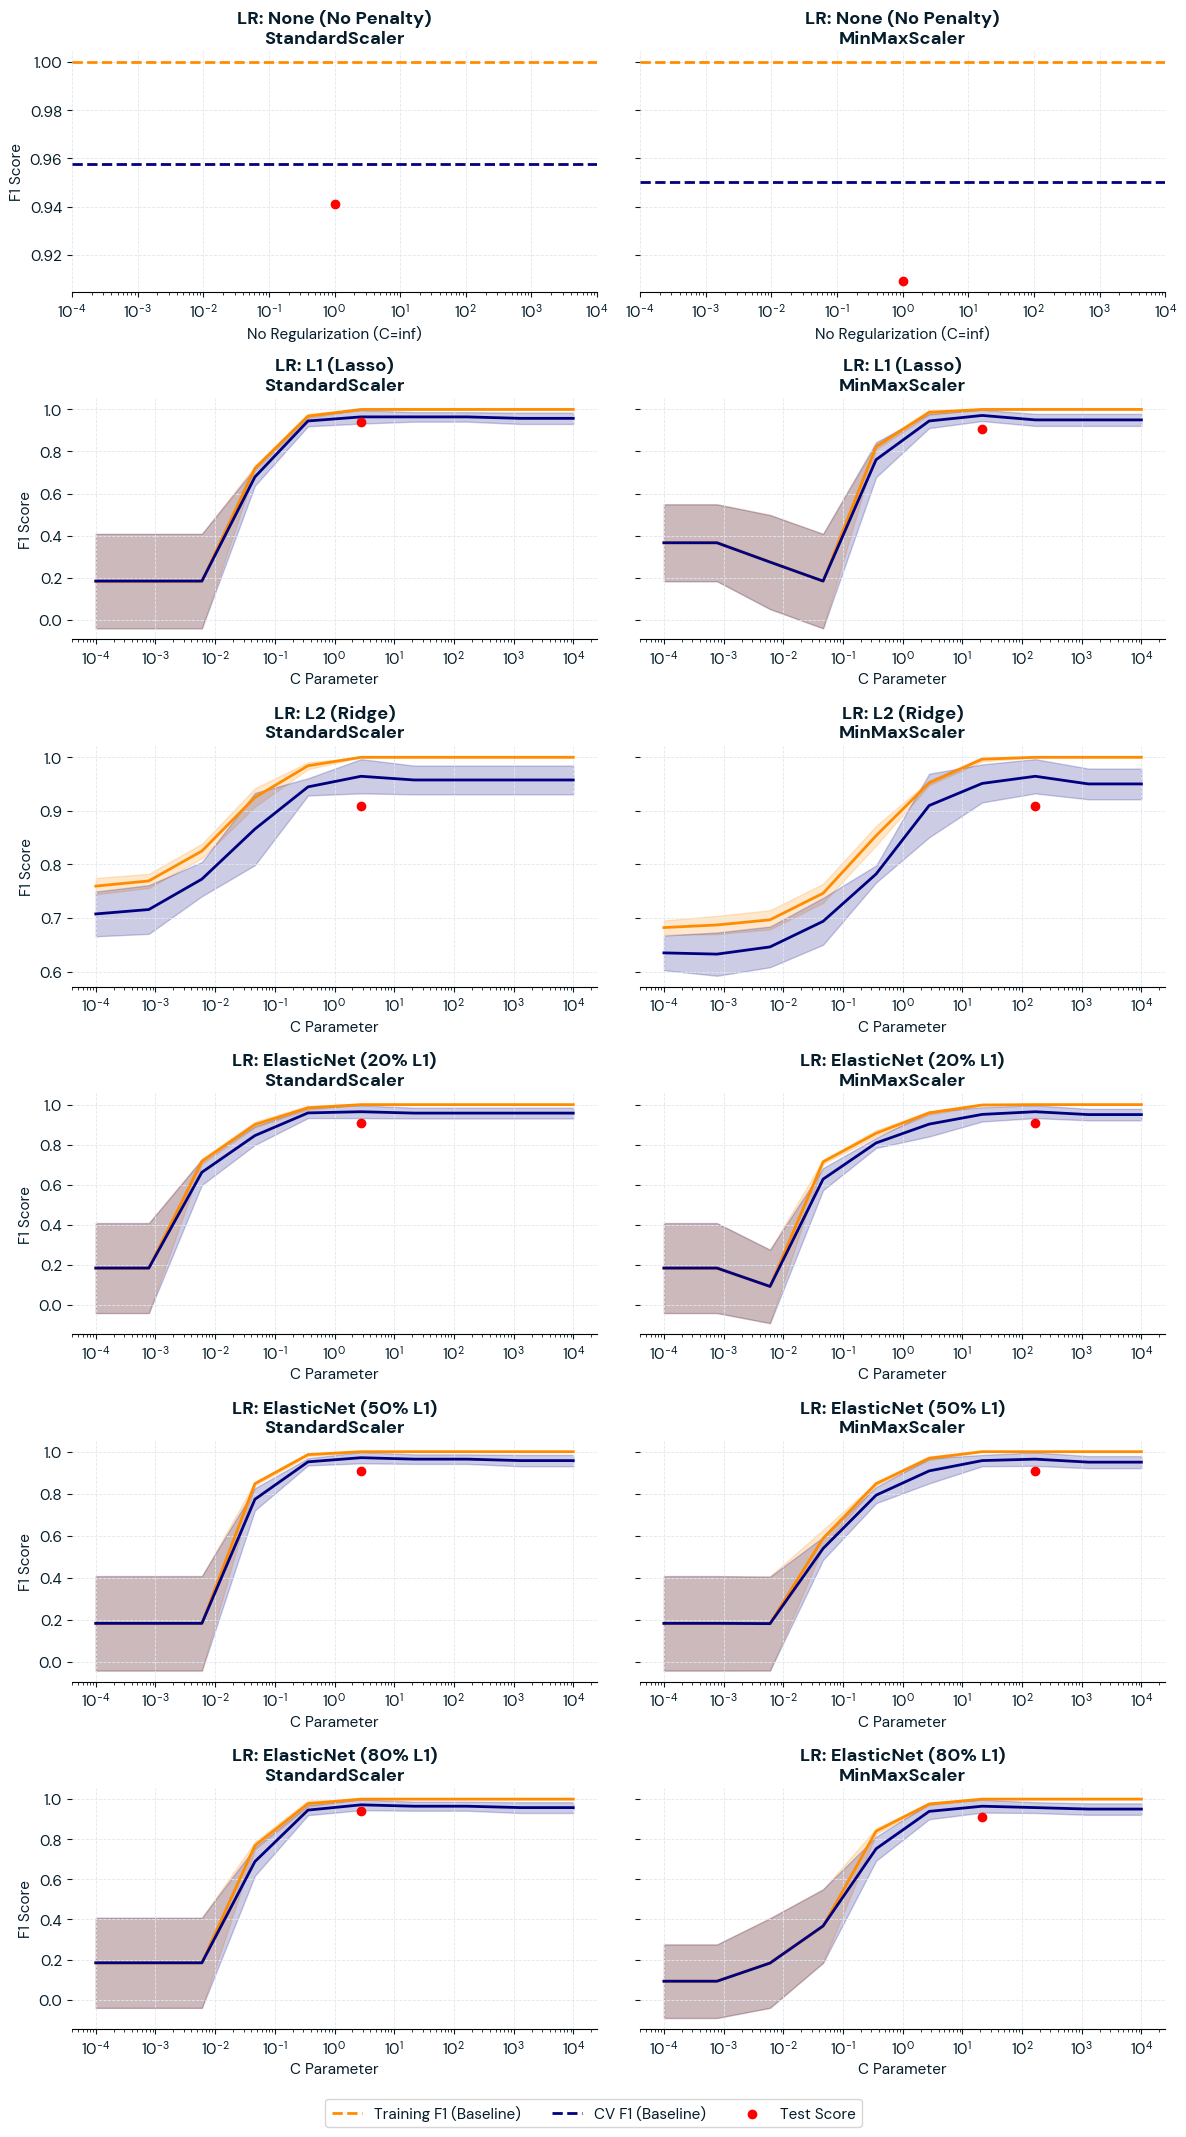


--- Logistic Regression Penalties Comparison ---
                                    accuracy precision    recall        f1  \
None (No Penalty)   StandardScaler  0.966102       1.0  0.888889  0.941176   
                    MinMaxScaler    0.949153       1.0  0.833333  0.909091   
L1 (Lasso)          StandardScaler  0.966102       1.0  0.888889  0.941176   
                    MinMaxScaler    0.949153       1.0  0.833333  0.909091   
L2 (Ridge)          StandardScaler  0.949153       1.0  0.833333  0.909091   
                    MinMaxScaler    0.949153       1.0  0.833333  0.909091   
ElasticNet (20% L1) StandardScaler  0.949153       1.0  0.833333  0.909091   
                    MinMaxScaler    0.949153       1.0  0.833333  0.909091   
ElasticNet (50% L1) StandardScaler  0.949153       1.0  0.833333  0.909091   
                    MinMaxScaler    0.949153       1.0  0.833333  0.909091   
ElasticNet (80% L1) StandardScaler  0.966102       1.0  0.888889  0.941176   
              

In [ ]:
# ==============================================================================
# PENALTY COMPARISON FOR LOGISTIC REGRESSION (Scikit-Learn 1.8+ Compliant)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score

# Define the configurations using the new scikit-learn 1.8 standard
# l1_ratio=1 is L1 (Lasso), l1_ratio=0 is L2 (Ridge)
configs = [
    {'name': 'None (No Penalty)', 'l1_ratio': None, 'is_none': True},
    {'name': 'L1 (Lasso)', 'l1_ratio': 1.0, 'is_none': False},
    {'name': 'L2 (Ridge)', 'l1_ratio': 0.0, 'is_none': False},
    {'name': 'ElasticNet (20% L1)', 'l1_ratio': 0.2, 'is_none': False},
    {'name': 'ElasticNet (50% L1)', 'l1_ratio': 0.5, 'is_none': False},
    {'name': 'ElasticNet (80% L1)', 'l1_ratio': 0.8, 'is_none': False}
]

scalers = [StandardScaler, MinMaxScaler]
c_range = np.logspace(-4, 4, 10)

ncols = len(scalers)
nrows = len(configs)
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(12, 3.5 * nrows), tight_layout=True, sharey='row')

results_penalties = {}

for row, config in enumerate(configs):
    for col, scaler_cls in enumerate(scalers):
        ax = axs[row, col]
        
        # --- NEW SKLEARN 1.8 LOGIC ---
        if config['is_none']:
            # For 'No Penalty', scikit-learn 1.8 requires C=np.inf
            model = LogisticRegression(
                C=np.inf, 
                solver='saga',
                max_iter=3000, 
                random_state=42,
                class_weight='balanced'
                # Notice 'penalty' is removed entirely!
            )
            pipe = Pipeline([('scaler', scaler_cls()), ('estimator', model)])
            # We don't grid search C if it's forced to infinity
            grid = GridSearchCV(pipe, {}, return_train_score=True, cv=5, scoring='f1', n_jobs=-1)
            best_param_value = "N/A"
        else:
            # For everything else, we just use l1_ratio
            model = LogisticRegression(
                l1_ratio=config['l1_ratio'],
                solver='saga',
                max_iter=3000,
                random_state=42,
                class_weight='balanced'
                # Notice 'penalty' is removed entirely!
            )
            pipe = Pipeline([('scaler', scaler_cls()), ('estimator', model)])
            # Grid search C normally
            grid = GridSearchCV(pipe, {'estimator__C': c_range}, return_train_score=True, cv=5, scoring='f1', n_jobs=-1)
            
        grid.fit(X_train, y_train)
        best_estimator = grid.best_estimator_
        
        # Predict
        y_test_pred = best_estimator.predict(X_test)
        y_test_score = f1_score(y_test, y_test_pred) 
        
        # --- Visualization Logic ---
        if not config['is_none']:
            best_param_value = grid.best_params_['estimator__C']
            
            res = grid.cv_results_
            train_mean = res['mean_train_score']
            train_std = res['std_train_score']
            test_mean = res['mean_test_score']
            test_std = res['std_test_score']
            
            ax.plot(c_range, train_mean, label="Training F1 Score", color="darkorange", lw=2)
            ax.fill_between(c_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")
            
            ax.plot(c_range, test_mean, label="Cross-validation F1 Score", color="navy", lw=2)
            ax.fill_between(c_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")
            
            ax.scatter(best_param_value, y_test_score, color='red', label='Test with best C', zorder=5)
            ax.set_xscale('log')
            ax.set_xlabel('C Parameter')
        else:
            # Plot flat lines for No Regularization (C=inf)
            train_mean = grid.cv_results_['mean_train_score'][0]
            test_mean = grid.cv_results_['mean_test_score'][0]
            
            ax.axhline(train_mean, label="Training F1 (Baseline)", color="darkorange", lw=2, linestyle='--')
            ax.axhline(test_mean, label="CV F1 (Baseline)", color="navy", lw=2, linestyle='--')
            ax.scatter(1.0, y_test_score, color='red', label='Test Score', zorder=5)
            
            ax.set_xscale('log')
            ax.set_xlim([c_range[0], c_range[-1]])
            ax.set_xlabel('No Regularization (C=inf)')

        # Formatting
        ax.set_title(f"LR: {config['name']}\n{scaler_cls.__name__}")
        if col != 0: ax.set_ylabel('')
        else: ax.set_ylabel('F1 Score')

        # Save Metrics
        metrics = compute_classification_metrics(y_test, y_test_pred, best_param_value)
        metrics['Best_C'] = best_param_value 
        results_penalties[(config['name'], scaler_cls.__name__)] = metrics

# Legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

plt.show()

# --- Summary Table ---
results_penalties_df = pd.DataFrame(results_penalties).T
print("\n--- Logistic Regression Penalties Comparison ---")
print(results_penalties_df)

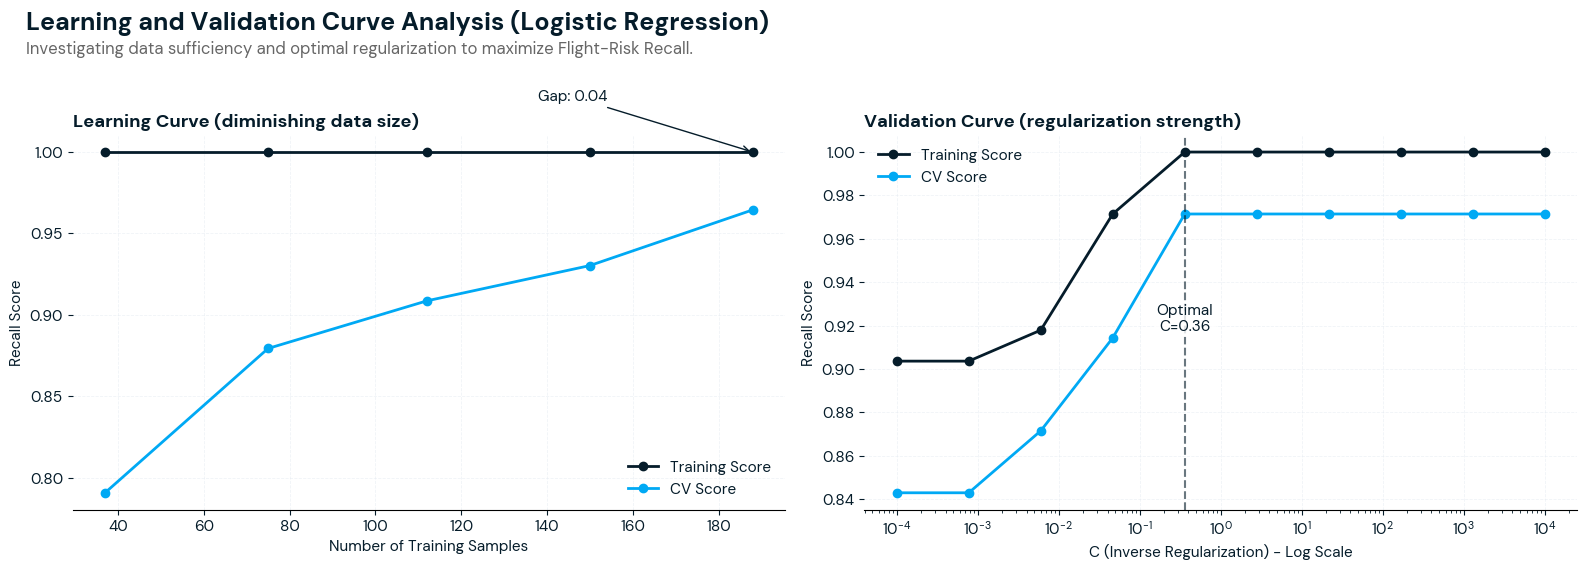

In [ ]:
#############################################################################################################
# LEARNING CURVE & VALIDATION CURVE ANALYSIS
#############################################################################################################


# learning curve 
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    best_overall_model, X_train, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
)

train_mean_lc = np.mean(train_scores_lc, axis=1)
test_mean_lc = np.mean(test_scores_lc, axis=1)

# validation curve for the best hyperparameter (C for Logistic Regression)
param_range = np.logspace(-4, 4, 10)
train_scores_vc, test_scores_vc = validation_curve(
    best_overall_model, X_train, y_train,
    param_name="estimator__C",
    param_range=param_range,
    cv=5, scoring="recall", n_jobs=-1
)
train_mean_vc = np.mean(train_scores_vc, axis=1)
test_mean_vc = np.mean(test_scores_vc, axis=1)

#plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#learning curve plot
axes[0].plot(train_sizes, train_mean_lc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes[0].plot(train_sizes, test_mean_lc, 'o-', color=BLUE2, label="CV Score", linewidth=2)
axes[0].set_title("Learning Curve (diminishing data size)", fontweight='bold', loc='left', color=PRIMARY)
axes[0].set_xlabel("Number of Training Samples")
axes[0].set_ylabel("Recall Score")
axes[0].legend(frameon=False, loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

#fix height of the gap annotation to be dynamic based on the data range
y_range_lc = max(train_mean_lc) - min(test_mean_lc)
dynamic_gap_offset = y_range_lc * 0.15 

#gap
gap = train_mean_lc[-1] - test_mean_lc[-1]
axes[0].annotate(f"Gap: {gap:.2f}", 
                 xy=(train_sizes[-1], train_mean_lc[-1]),
                 xytext=(train_sizes[-1]-50, train_mean_lc[-1] + dynamic_gap_offset),
                 arrowprops=dict(arrowstyle="->", color=ACCENT),
                 color=ACCENT)

#validation curve plot
axes[1].semilogx(param_range, train_mean_vc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes[1].semilogx(param_range, test_mean_vc, 'o-', color=BLUE2, label="CV Score", linewidth=2)
axes[1].set_title("Validation Curve (regularization strength)", fontweight='bold', loc='left', color=PRIMARY)
axes[1].set_xlabel("C (Inverse Regularization) - Log Scale")
axes[1].set_ylabel("Recall Score")
axes[1].legend(frameon=False, loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

#optimal c
best_idx = np.argmax(test_mean_vc)
optimal_c = param_range[best_idx]
axes[1].axvline(optimal_c, color=ACCENT, linestyle='--', alpha=0.6)

#fixed annotation position to be dynamic based on the data range
axes[1].text(optimal_c, 0.55, f"Optimal\nC={optimal_c:.2f}",
             transform=axes[1].get_xaxis_transform(),
             color=ACCENT, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

fig.text(0.02, 0.96, "Learning and Validation Curve Analysis (Logistic Regression)",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Investigating data sufficiency and optimal regularization to maximize Flight-Risk Recall.",
         fontsize=12, ha='left', color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

fig.savefig("Learning Curve and Validation Curve.png", dpi =150)

We observe that Logistic Regression shows the best results, it achieves the highest accuracy as well as recall. AdaBoostClassifier shows the same results as Logistic Regression; However, looking at the graph, it shows moderate overfitting. RandomForest and HistGradientBoosting show severe overfitting, as well as lower overall metrics. Therefore we will proceed with LogReg and tweak the hyperparameters to achieve better results. We will run all models with optimized hyperparameters one more time to see if results differ.

Note: The results of the tweaked models were worse so we will ignore those.

After tweaking hyperparameters, the other models do not show any improvement. Therefore we will proceed with Logistic Regression.

Logistic Regression using StandardScaler shows impressive results, with an accuracy of 94%, precision of 100%, recall of 83% and a f1 score of 90%.

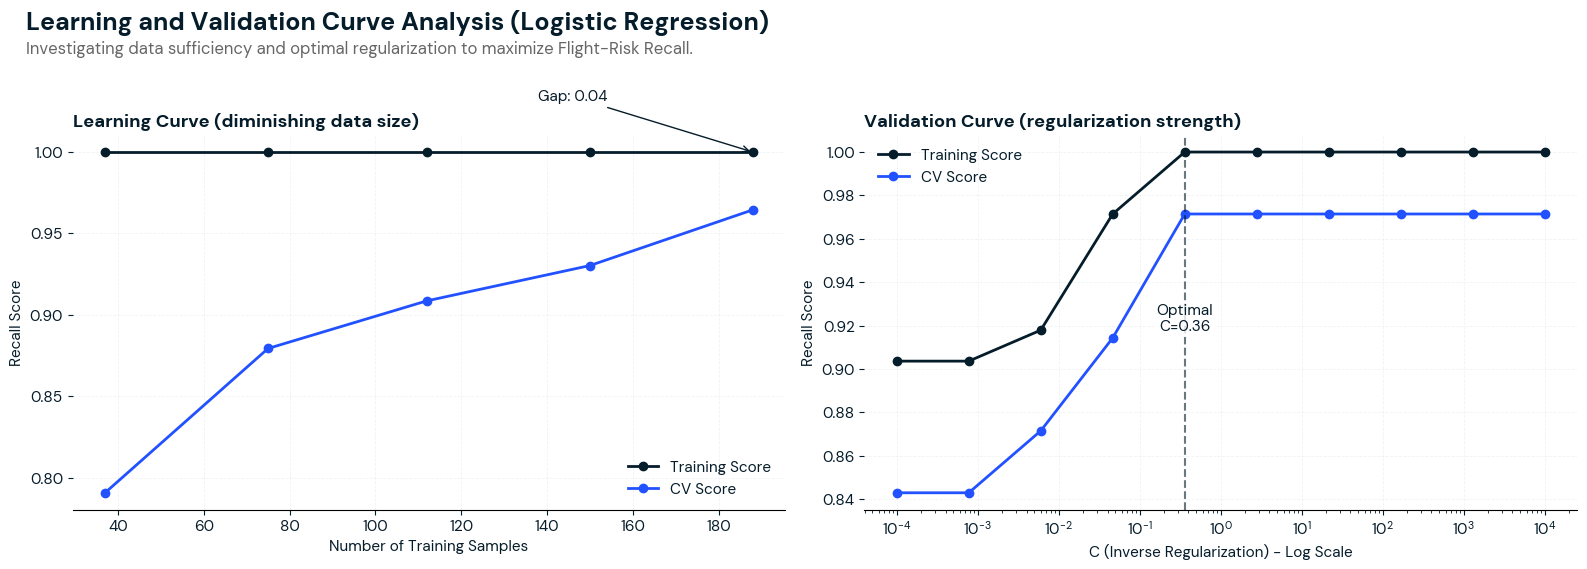

In [ ]:
#############################################################################################################
# LEARNING CURVE & VALIDATION CURVE ANALYSIS
#############################################################################################################


# learning curve 
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    best_overall_model, X_train, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
)

train_mean_lc = np.mean(train_scores_lc, axis=1)
test_mean_lc = np.mean(test_scores_lc, axis=1)

# validation curve for the best hyperparameter (C for Logistic Regression)
param_range = np.logspace(-4, 4, 10)
train_scores_vc, test_scores_vc = validation_curve(
    best_overall_model, X_train, y_train,
    param_name="estimator__C",
    param_range=param_range,
    cv=5, scoring="recall", n_jobs=-1
)
train_mean_vc = np.mean(train_scores_vc, axis=1)
test_mean_vc = np.mean(test_scores_vc, axis=1)

#plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#learning curve plot
axes[0].plot(train_sizes, train_mean_lc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes[0].plot(train_sizes, test_mean_lc, 'o-', color=BLUE, label="CV Score", linewidth=2)
axes[0].set_title("Learning Curve (diminishing data size)", fontweight='bold', loc='left', color=PRIMARY)
axes[0].set_xlabel("Number of Training Samples")
axes[0].set_ylabel("Recall Score")
axes[0].legend(frameon=False, loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

#fix height of the gap annotation to be dynamic based on the data range
y_range_lc = max(train_mean_lc) - min(test_mean_lc)
dynamic_gap_offset = y_range_lc * 0.15 

#gap
gap = train_mean_lc[-1] - test_mean_lc[-1]
axes[0].annotate(f"Gap: {gap:.2f}", 
                 xy=(train_sizes[-1], train_mean_lc[-1]),
                 xytext=(train_sizes[-1]-50, train_mean_lc[-1] + dynamic_gap_offset),
                 arrowprops=dict(arrowstyle="->", color=ACCENT),
                 color=ACCENT)

#validation curve plot
axes[1].semilogx(param_range, train_mean_vc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes[1].semilogx(param_range, test_mean_vc, 'o-', color=BLUE, label="CV Score", linewidth=2)
axes[1].set_title("Validation Curve (regularization strength)", fontweight='bold', loc='left', color=PRIMARY)
axes[1].set_xlabel("C (Inverse Regularization) - Log Scale")
axes[1].set_ylabel("Recall Score")
axes[1].legend(frameon=False, loc='best')
axes[1].grid(True, linestyle='--', alpha=0.5)

#optimal c
best_idx = np.argmax(test_mean_vc)
optimal_c = param_range[best_idx]
axes[1].axvline(optimal_c, color=ACCENT, linestyle='--', alpha=0.6)

#fixed annotation position to be dynamic based on the data range
axes[1].text(optimal_c, 0.55, f"Optimal\nC={optimal_c:.2f}",
             transform=axes[1].get_xaxis_transform(),
             color=ACCENT, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

fig.text(0.02, 0.96, "Learning and Validation Curve Analysis (Logistic Regression)",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Investigating data sufficiency and optimal regularization to maximize Flight-Risk Recall.",
         fontsize=12, ha='left', color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

In [ ]:
best_overall_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, ma

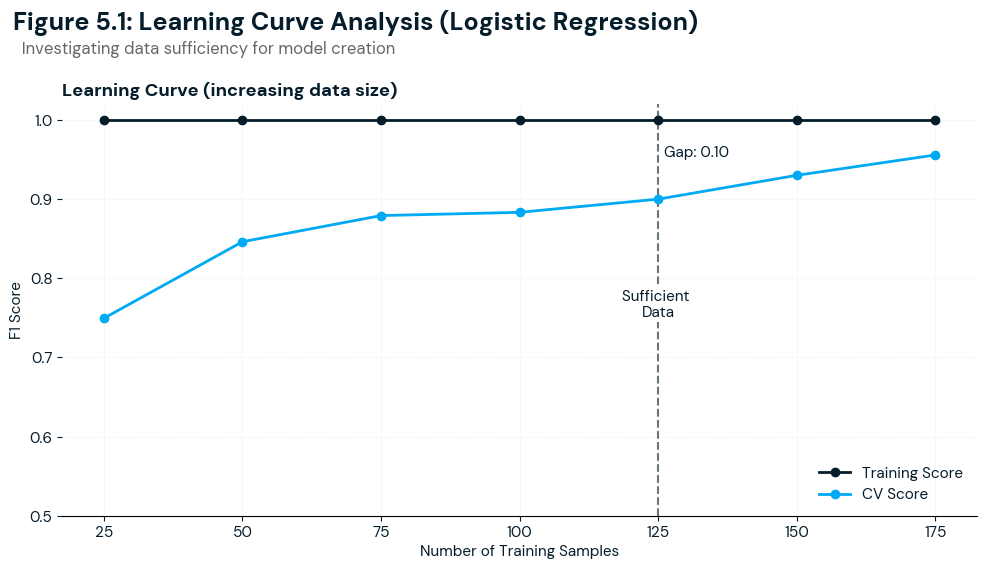

In [ ]:
#Learning Curve Export for the Report:

# learning curve 
train_sizes, train_scores_lc, test_scores_lc = learning_curve(
    best_overall_model, X_train, y_train, cv=5, scoring='f1',
    train_sizes=[25,50, 75, 100, 125, 150, 175], n_jobs=-1
)

train_mean_lc = np.mean(train_scores_lc, axis=1)
test_mean_lc = np.mean(test_scores_lc, axis=1)


fig, axes = plt.subplots(1, 1, figsize=(10, 6))

#learning curve plot
axes.axvline(125, color=ACCENT, linestyle='--', alpha=0.6)
axes.plot(train_sizes, train_mean_lc, 'o-', color=PRIMARY, label="Training Score", linewidth=2)
axes.plot(train_sizes, test_mean_lc, 'o-', color=BLUE2, label="CV Score", linewidth=2)
axes.set_title("Learning Curve (increasing data size)", fontweight='bold', loc='left', color=PRIMARY)
axes.set_xlabel("Number of Training Samples")
axes.set_xticks([25,50, 75, 100, 125, 150, 175])
axes.set_ylabel("F1 Score")
axes.legend(frameon=False, loc='lower right')
axes.grid(True, linestyle='--', alpha=0.5)
axes.set_ylim(0.5, 1.02)
axes.text(125, 0.55, f"Sufficient \nData",
             transform=axes.get_xaxis_transform(),
             color=ACCENT, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2))


#fix height of the gap annotation to be dynamic based on the data range
y_range_lc = max(train_mean_lc) - min(test_mean_lc)
dynamic_gap_offset = y_range_lc * 0.15 

#gap
gap = train_mean_lc[-3] - test_mean_lc[-3]
axes.text(126, 0.9, f"Gap: {gap:.2f}", 
            transform=axes.get_xaxis_transform(),
            color=ACCENT, ha='left', va='top', 
            bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2))

fig.text(0.02, 0.96, "Figure 5.1: Learning Curve Analysis (Logistic Regression)",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "  Investigating data sufficiency for model creation ",
         fontsize=12, ha='left', color='#666666')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()


fig.savefig("Learning Curve.png", dpi =300)

c:\Users\Kéan\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


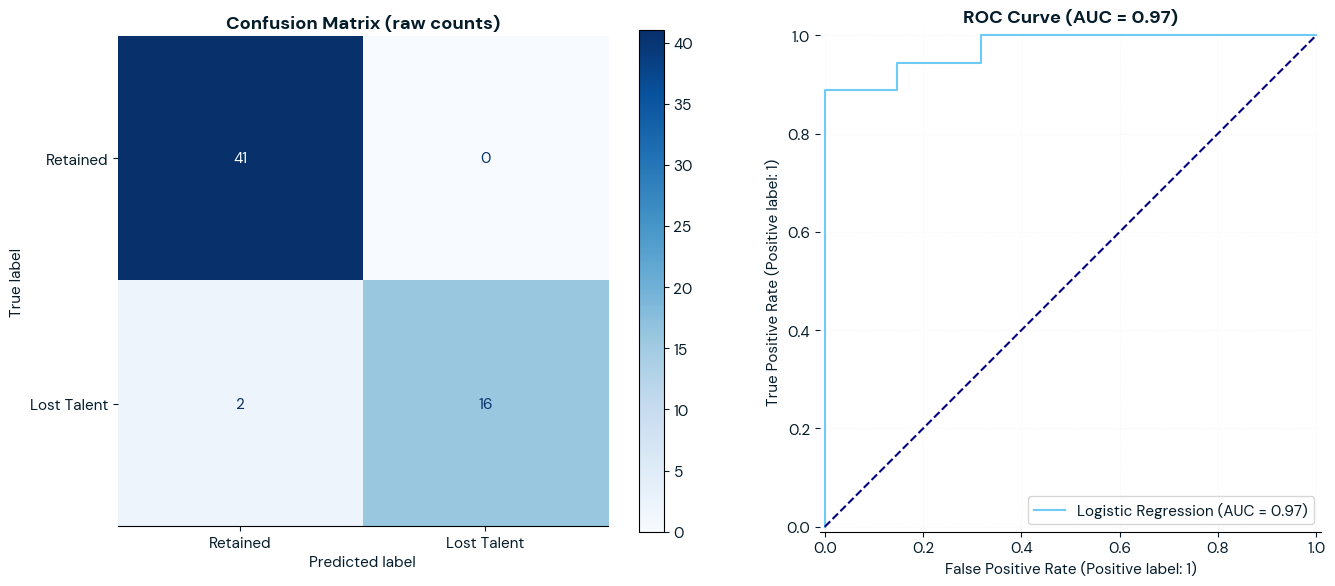


Classification Report
                 precision    recall  f1-score   support

   Retained (0)       0.95      1.00      0.98        41
Lost Talent (1)       1.00      0.89      0.94        18

       accuracy                           0.97        59
      macro avg       0.98      0.94      0.96        59
   weighted avg       0.97      0.97      0.97        59



In [ ]:
#############################################################################################################
# FINAL EVALUATION OF WINNING MODEL
#############################################################################################################

best_model = Pipeline([
    ('scaler', StandardScaler()), 
    ('estimator', LogisticRegression(
        C=0.36, 
        max_iter=20000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ))
])

# Train winning model
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] # P(Turnover)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[0],
    cmap='Blues',
    normalize=None,
    display_labels=['Retained', 'Lost Talent']
)
axes[0].set_title("Confusion Matrix (raw counts)")
axes[0].grid(False) # Grid lines make confusion matrices look messy

# ROC curve
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    ax=axes[1],
    color= BLUE3,
    name='Logistic Regression'
)

axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.2f})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Lost Talent (1)']))

# 6. Advanced Analytics (survival & explainability)

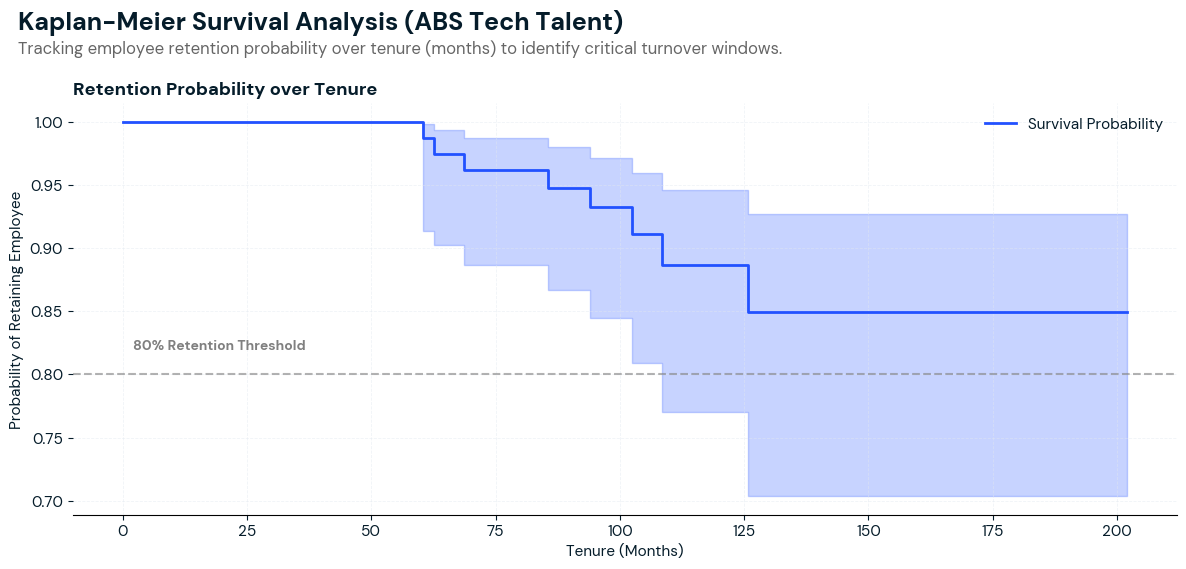

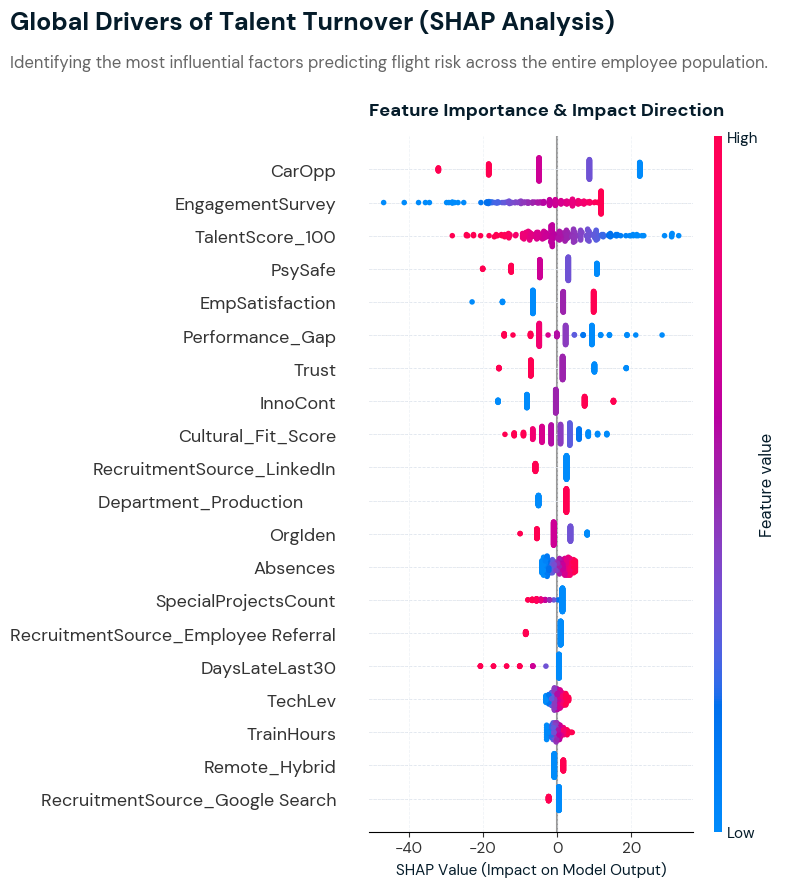

In [ ]:
#############################################################################################################
# SURVIVAL ANALYSIS & MODEL INTERPRETABILITY
#############################################################################################################


#Survival Analysis with Kaplan-Meier Curves
#Want to show CEO that the risk of losing top talent increases significantly after a certain tenure threshold, which can inform retention strategies and critical intervention points.
talent_df = df_clean[df_clean['Is_Talent'] == 1].copy()

kmf = KaplanMeierFitter()

# Fit the Kaplan-Meier model on Tenure and Voluntary Turnover
kmf.fit(
    durations=talent_df['Tenure_Months'], 
    event_observed=talent_df['Target_Voluntary_Turnover'],
    label='High-Talent Retention Probability'
)

#plotting
fig, ax = plt.subplots(figsize=(12, 6))

kmf.plot_survival_function(ax=ax, color=BLUE, linewidth=2, label="Survival Probability")

fig.text(0.02, 0.96, "Kaplan-Meier Survival Analysis (ABS Tech Talent)", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Tracking employee retention probability over tenure (months) to identify critical turnover windows.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Retention Probability over Tenure', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Tenure (Months)', fontsize=11)
ax.set_ylabel('Probability of Retaining Employee', fontsize=11)

ax.legend(frameon=False, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

ax.axhline(y=0.80, color='gray', linestyle='--', alpha=0.6)
ax.text(2, 0.82, '80% Retention Threshold', color='gray', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('styled_kaplan_meier.svg', format='svg', bbox_inches='tight')
plt.show()

#SHAP values for global feature importance and interpretability of the best model
best_scaler = best_overall_model.named_steps['scaler']
best_estimator = best_overall_model.named_steps['estimator']

#scaling the training data using the best scaler to ensure SHAP values are calculated in the same feature space as the model was trained on
X_train_scaled = best_scaler.transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

#initialize
if type(best_estimator).__name__ == 'LogisticRegression':
    explainer = shap.LinearExplainer(best_estimator, X_train_scaled_df)
else:
    explainer = shap.TreeExplainer(best_estimator)

#calculate SHAP values
shap_values = explainer(X_train_scaled_df)

#Plotting
fig = plt.figure(figsize=(12, 8))

shap.summary_plot(shap_values, X_train_scaled_df, show=False)

fig.text(0.02, 0.96, "Global Drivers of Talent Turnover (SHAP Analysis)", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Identifying the most influential factors predicting flight risk across the entire employee population.", 
         fontsize=12, ha='left', color='#666666')

ax = plt.gca() 
ax.set_title('Feature Importance & Impact Direction', fontweight='bold', loc='left', color=PRIMARY, pad=15)
ax.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=11)

ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])

plt.savefig('styled_shap_summary.svg', format='svg', bbox_inches='tight')
plt.show()

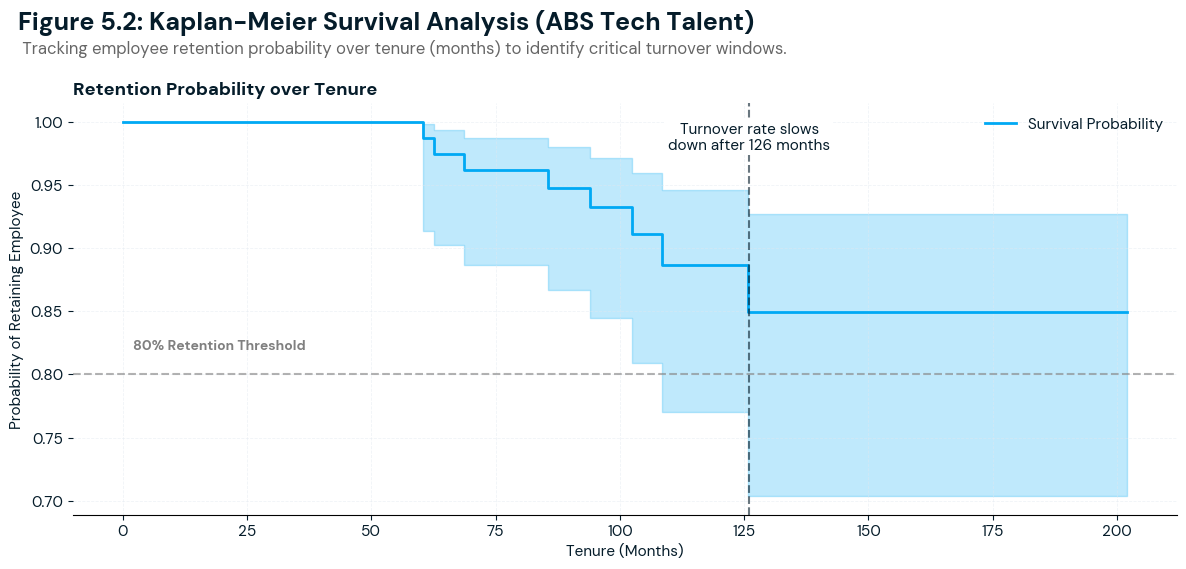

In [ ]:
talent_df = df_clean[df_clean['Is_Talent'] == 1].copy()

kmf = KaplanMeierFitter()

# Fit the Kaplan-Meier model on Tenure and Voluntary Turnover
kmf.fit(
    durations=talent_df['Tenure_Months'], 
    event_observed=talent_df['Target_Voluntary_Turnover'],
    label='High-Talent Retention Probability'
)

#plotting
fig, ax = plt.subplots(figsize=(12, 6))

kmf.plot_survival_function(ax=ax, color=BLUE2, linewidth=2, label="Survival Probability")

fig.text(0.02, 0.96, "Figure 5.2: Kaplan-Meier Survival Analysis (ABS Tech Talent)", 
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, " Tracking employee retention probability over tenure (months) to identify critical turnover windows.", 
         fontsize=12, ha='left', color='#666666')

ax.set_title('Retention Probability over Tenure', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Tenure (Months)', fontsize=11)
ax.set_ylabel('Probability of Retaining Employee', fontsize=11)
ax.axvline(126, color=ACCENT, linestyle='--', alpha=0.6)
ax.text(126, 1, f"Turnover rate slows\ndown after 126 months",
             color=ACCENT, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=2))

ax.legend(frameon=False, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

ax.axhline(y=0.80, color='gray', linestyle='--', alpha=0.6)
ax.text(2, 0.82, '80% Retention Threshold', color='gray', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig('Kaplan-Meier Survival Analysis.svg', format='svg', bbox_inches='tight')
plt.show()




# 7. Business Value & ROI

In [ ]:
#############################################################################################################
#BUSINESS VALUE SIMULATION
#############################################################################################################


#isolate active employees from the original dataframe to ensure we have the Employee Names and Salary for the final report
active_indices = df[df['EmploymentStatus'] == 'Active'].index
valid_active_indices = active_indices.intersection(df_clean.index)

active_pool = df_clean.loc[valid_active_indices].copy()

#prepare features
existing_features = [col for col in (num_features + cat_features) if col in active_pool.columns]
X_active = active_pool[existing_features]

# OHE
X_active_encoded = pd.get_dummies(X_active, columns=cat_features, drop_first=True)
X_active_encoded = X_active_encoded.reindex(columns=X_train.columns, fill_value=0)


#predictive 'red alert' watchlist using the best model to identify the top 5 active talents at highest risk of turnover
active_pool['Turnover_Prob'] = best_overall_model.predict_proba(X_active_encoded)[:, 1]

#isolate the active talent pool for the final report
talent_active = active_pool[active_pool['Is_Talent'] == 1].copy()

#generate the 'red alert' watchlist of the top 5 active talents with the highest predicted turnover probabilities
red_alert_list = talent_active.nlargest(5, 'Turnover_Prob').copy()


#Financial ROI calculation based on the predicted turnover risk and the average salary of the top 5 at-risk talents.
#CAN BE CHANGED
cost_multiplier = 1.5 
value_at_risk = (red_alert_list['Salary'] * cost_multiplier).sum()


#Prescriptive action recommendations based on the key drivers of turnover risk identified in the SHAP analysis and significant driver analysis.
#CAN BE CHANGED
def prescribe_action(row):
    if row['Work_Life_Indicator'] <= 3.0:
        return "Approve Remote/Hybrid Flexibility"
    elif row['PsySafe'] <= 3.0:
        return "Managerial 1-on-1 & Psychological Safety Audit"
    elif row['TrainHours'] < 40:
        return "Allocate €1,000 Upskilling & Certification Budget"
    elif row['Performance_Gap'] < -1: 
        return "Review Compensation & Fast-Track Promotion"
    else:
        return "Conduct Immediate Stay Interview"

red_alert_list['Recommended_Action'] = red_alert_list.apply(prescribe_action, axis=1)


#Dashboard preparation: selecting and formatting the key information for the CEO, including employee names, predicted turnover probabilities, talent scores, salaries, and recommended actions.
dashboard_cols = ['Employee.Name', 'Turnover_Prob', 'TalentScore_100', 'Salary', 'Recommended_Action']
final_dashboard = red_alert_list[dashboard_cols].sort_values(by='Turnover_Prob', ascending=False)

final_dashboard['Turnover_Prob'] = (final_dashboard['Turnover_Prob'] * 100).round(1).astype(str) + '%'
final_dashboard['TalentScore_100'] = final_dashboard['TalentScore_100'].round(1)

print("==========================================================")
print("             ABS TECH - C-SUITE RETENTION DASHBOARD       ")
print("==========================================================\n")
print(f"Active Talents Monitored: {len(talent_active)}")
print(f"Talents on 'Red Alert' Watchlist (Top 5 Risks): {len(red_alert_list)}\n")
print(f"TOTAL TALENT VALUE AT RISK: €{value_at_risk:,.2f}")
print("If our recommendations reduce this turnover by just 25%, ")
print(f"ABS Tech will save €{(value_at_risk * 0.25):,.2f} this year.\n")
print("==========================================================")
print("PRIORITY INTERVENTION LIST (TOP 5 RISKS):")
print(final_dashboard.to_string(index=False))

             ABS TECH - C-SUITE RETENTION DASHBOARD       

Active Talents Monitored: 71
Talents on 'Red Alert' Watchlist (Top 5 Risks): 5

TOTAL TALENT VALUE AT RISK: €530,635.50
If our recommendations reduce this turnover by just 25%, 
ABS Tech will save €132,658.88 this year.

PRIORITY INTERVENTION LIST (TOP 5 RISKS):
    Employee.Name Turnover_Prob  TalentScore_100  Salary                             Recommended_Action
  Hutter, Rosalie          0.1%             62.2   64995              Approve Remote/Hybrid Flexibility
  Fidelia,  Libby          0.1%             67.2   58530              Approve Remote/Hybrid Flexibility
   Gonzalez, Cayo          0.0%             66.5   59892 Managerial 1-on-1 & Psychological Safety Audit
Boutwell, Bonalyn          0.0%             65.2  106367 Managerial 1-on-1 & Psychological Safety Audit
 Kretschmer, John          0.0%             62.2   63973              Approve Remote/Hybrid Flexibility


# Final Model and Dashboard Creation: Radin's Addition

In [ ]:
num_features = [ 
    'Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount',
    'DaysLateLast30', 'Absences', 'TechLev', 'TrainHours', 'InnoCont',
    'CarOpp', 'PsySafe', 'Trust', 'TeamIden', 'OrgIden', 'TalentScore_100'
]
cat_features = ['Department', 'RecruitmentSource','Remote']


In [ ]:
# Add original index before any ops
df_clean['original_index'] = df_clean.index

df_majority = df_clean[df_clean['Target_Voluntary_Turnover'] == 0]
df_minority = df_clean[df_clean['Target_Voluntary_Turnover'] == 1]

# Take the 88 with longest tenure from majority
df_majority_sampled = df_majority[df_majority['Tenure_Months']>120]
df_active_analysis = df_majority.drop(df_majority_sampled.index).reset_index(drop=True)
df_model = pd.concat([df_majority_sampled, df_minority]).reset_index(drop=True)

# Extract X/y
X = df_model[num_features + cat_features]
y = df_model['Target_Voluntary_Turnover']

# Split WITHOUT shuffling indices
train_idx, test_idx = train_test_split(df_model.index, test_size=0.3, random_state=42, stratify=y)
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder



preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
])


# --- Build Pipeline ---


pipeline = Pipeline([
    ("preprocessor", preprocessor),

    
    ("clf", LogisticRegression(
        penalty="l1",       # Lasso norm
        solver="saga",      # Required for L1 penalty
        max_iter=5000,
        random_state=42,
    )),
])

# --- Define Parameter Grid ---
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
}

# --- Grid Search CV ---
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

# --- Results ---
print(f"Best C:        {grid_search.best_params_['clf__C']}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

y_pred = grid_search.best_estimator_.predict(X_test)
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred))




Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C:        10
Best CV score: 0.9362

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.93      0.96        27

    accuracy                           0.96        47
   macro avg       0.95      0.96      0.96        47
weighted avg       0.96      0.96      0.96        47



c:\Users\Kéan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Kéan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [ ]:
best_model = grid_search.best_estimator_
log_reg = best_model.named_steps["clf"]
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
import pandas as pd
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_reg.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df.iloc[:12,:])
coef_df.iloc[:12,:].to_csv("Predictor model Feature Importance.csv", sep = ',')


                       feature  coefficient
9                       CarOpp   -15.740914
1             EngagementSurvey    13.187957
10                     PsySafe   -12.328866
11                       Trust    -9.665426
14             TalentScore_100    -9.366949
2              EmpSatisfaction     9.045098
6                      TechLev     3.629864
29              Remote_On-site     1.499476
0                       Salary    -1.343454
28               Remote_Hybrid     1.327320
8                     InnoCont     1.234278
24  RecruitmentSource_LinkedIn     0.939600


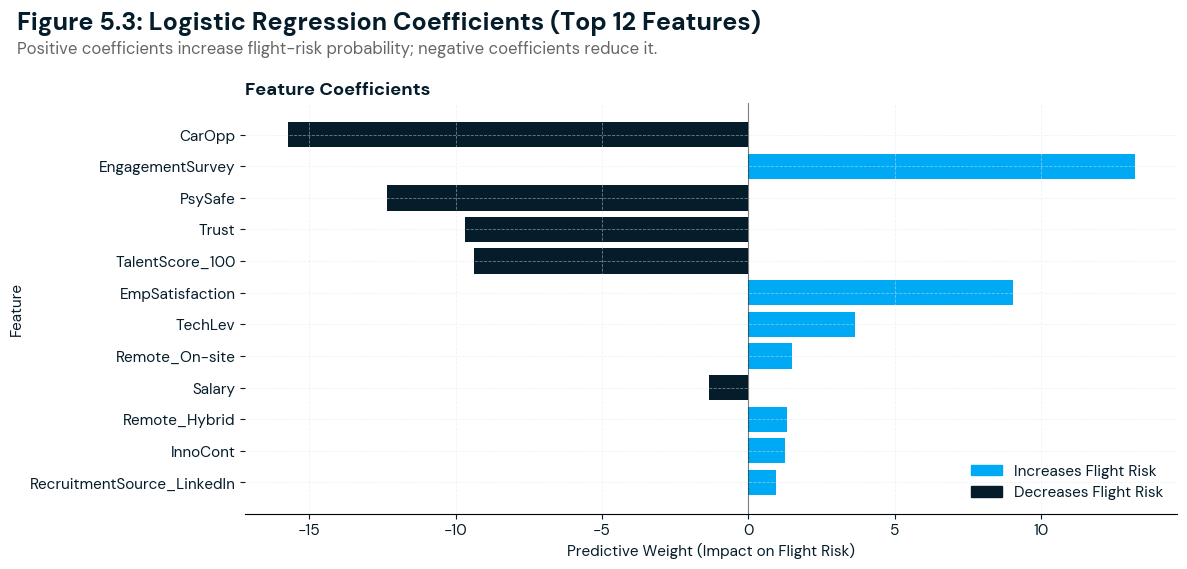

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

coef_data = coef_df.iloc[:12, :]
colors = [BLUE2 if x > 0 else ACCENT for x in coef_data['coefficient']]

ax.barh(coef_data['feature'], coef_data['coefficient'], color=colors, edgecolor='none')

fig.text(0.02, 0.96, "Figure 5.3: Logistic Regression Coefficients (Top 12 Features)",
         fontsize=18, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.92, "Positive coefficients increase flight-risk probability; negative coefficients reduce it.",
         fontsize=12, ha='left', color='#666666')
ax.invert_yaxis()
ax.set_title('Feature Coefficients', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Predictive Weight (Impact on Flight Risk)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=BLUE2, label='Increases Flight Risk'),
    plt.Rectangle((0,0),1,1, color=ACCENT, label='Decreases Flight Risk')
], frameon=False, loc='lower right')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()
fig.savefig("Logistic Regression Coefficients")

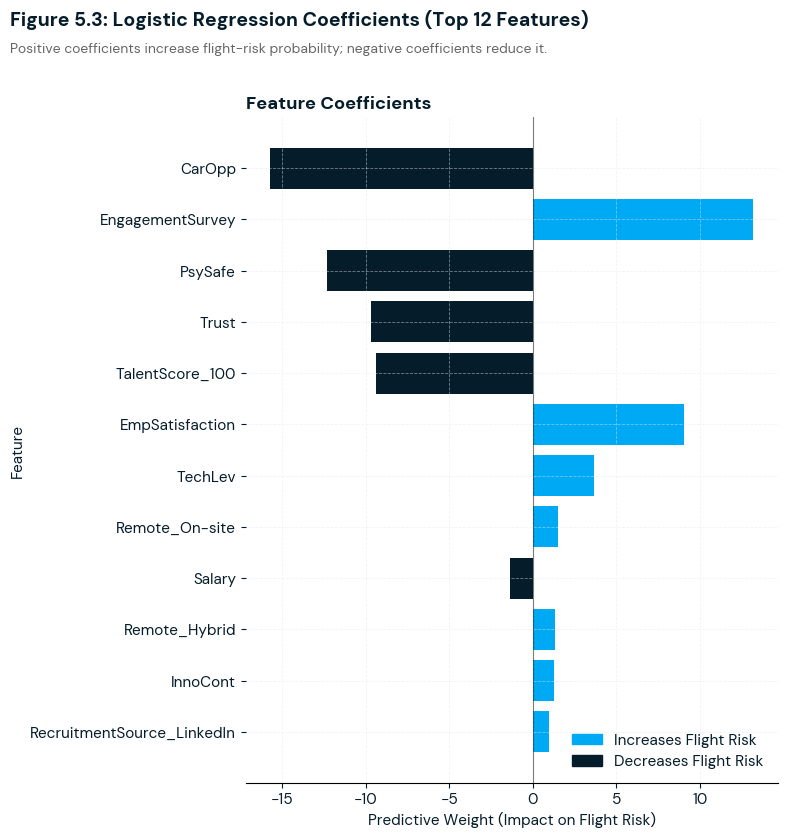

In [ ]:
# Updated figsize to match the ~8:9 aspect ratio of the template
fig, ax = plt.subplots(figsize=(8, 9)) 

coef_data = coef_df.iloc[:12, :]
colors = [BLUE2 if x > 0 else ACCENT for x in coef_data['coefficient']]

ax.barh(coef_data['feature'], coef_data['coefficient'], color=colors, edgecolor='none')

# Scaled down fontsize slightly to fit the narrower figure width
fig.text(0.02, 0.96, "Figure 5.3: Logistic Regression Coefficients (Top 12 Features)",
         fontsize=14, fontweight='700', ha='left', color=PRIMARY)
fig.text(0.02, 0.93, "Positive coefficients increase flight-risk probability; negative coefficients reduce it.",
         fontsize=10, ha='left', color='#666666')

ax.invert_yaxis()
ax.set_title('Feature Coefficients', fontweight='bold', loc='left', color=PRIMARY)
ax.set_xlabel('Predictive Weight (Impact on Flight Risk)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=BLUE2, label='Increases Flight Risk'),
    plt.Rectangle((0,0),1,1, color=ACCENT, label='Decreases Flight Risk')
], frameon=False, loc='lower right')

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.savefig("Logistic Regression Coefficients vertical.svg", format='svg', bbox_inches='tight')
plt.show()


In [ ]:
X_active_analysis = df_active_analysis[num_features + cat_features]


y_prediction_active_pool = grid_search.best_estimator_.predict_proba(X_active_analysis)

df_active_analysis['Turnover_Probability'] = y_prediction_active_pool[:,1]


high_risk_idx = df_active_analysis['Turnover_Probability'].nlargest(5).index
print("Top 5 high-risk employees:")
print(df_active_analysis.loc[high_risk_idx][['Employee.Name', 'Turnover_Probability', 'original_index','Salary']])

Top 5 high-risk employees:
          Employee.Name  Turnover_Probability  original_index  Salary
115      Shields, Seffi              0.893492             253   52087
45      Gentry, Mildred              0.846904             102   51337
2    Bacong, Alejandro               0.631074               9   50178
9    Buccheri, Joseph                0.564895              30   65288
54      Gray, Elijiah                0.549715             118   62957


### Dashboard

In [ ]:

#generate the 'red alert' watchlist of the top 5 active talents with the highest predicted turnover probabilities
df_active_analysis['Talent_risk_factor'] = df_active_analysis['TalentScore_100']*df_active_analysis['Turnover_Probability']
# df_talent_pool = df_active_analysis[df_active_analysis['TalentScore_100']>62]
df_talent_pool = df_active_analysis
red_alert_list = df_talent_pool.nlargest(5, 'Talent_risk_factor').copy()

#join back the Employee Names for the final dashboard (since we had to drop them during modeling for privacy reasons)


#Financial ROI calculation based on the predicted turnover risk and the average salary of the top 5 at-risk talents.
#CAN BE CHANGED
cost_multiplier = 1.5 
value_at_risk = (red_alert_list['Salary'] * cost_multiplier).sum()


#Prescriptive action recommendations based on the key drivers of turnover risk identified in the SHAP analysis and significant driver analysis.
#CAN BE CHANGED
def prescribe_action(row):
    if row['Cultural_Fit_Score'] <= 2.0:
        return "Consider changing team or engaging in company culture"
    elif row['Work_Life_Indicator'] <= 3.0:
        return "Approve Remote/Hybrid Flexibility"
    elif row['PsySafe'] <= 3.0:
        return "Managerial 1-on-1 & Psychological Safety Audit"
    elif row['TrainHours'] < 40:
        return "Allocate €1,000 Upskilling & Certification Budget"
    elif row['Performance_Gap'] < -1: 
        return "Review Compensation & Fast-Track Promotion"
    else:
        return "Conduct Immediate Stay Interview"

red_alert_list['Recommended_Action'] = red_alert_list.apply(prescribe_action, axis=1)


#Dashboard preparation: selecting and formatting the key information for the CEO, including employee names, predicted turnover probabilities, talent scores, salaries, and recommended actions.
dashboard_cols = ['Employee.Name', 'Turnover_Probability', 'TalentScore_100', 'Salary', 'Recommended_Action']
final_dashboard = red_alert_list[dashboard_cols].sort_values(by='Turnover_Probability', ascending=False)

final_dashboard['Turnover_Probability'] = (final_dashboard['Turnover_Probability'] * 100).round(1).astype(str) + '%'
final_dashboard['TalentScore_100'] = final_dashboard['TalentScore_100'].round(1)

print("==========================================================")
print("             ABS TECH - C-SUITE RETENTION DASHBOARD       ")
print("==========================================================\n")
print(f"Active Talents Monitored: {len(df_active_analysis)}")
print(f"Talents on 'Red Alert' Watchlist (Top 5 Risks): {len(red_alert_list)}\n")
print(f"TOTAL TALENT VALUE AT RISK: €{value_at_risk:,.2f}")
print("If our recommendations reduce this turnover by just 25%, ")
print(f"ABS Tech will save €{(value_at_risk * 0.25):,.2f} this year.\n")
print("==========================================================")
print("PRIORITY INTERVENTION LIST (TOP 5 RISKS):")
print(final_dashboard.to_string(index=False))

             ABS TECH - C-SUITE RETENTION DASHBOARD       

Active Talents Monitored: 140
Talents on 'Red Alert' Watchlist (Top 5 Risks): 5

TOTAL TALENT VALUE AT RISK: €468,718.50
If our recommendations reduce this turnover by just 25%, 
ABS Tech will save €117,179.62 this year.

PRIORITY INTERVENTION LIST (TOP 5 RISKS):
     Employee.Name Turnover_Probability  TalentScore_100  Salary                             Recommended_Action
    Shields, Seffi                89.3%             44.7   52087              Approve Remote/Hybrid Flexibility
   Gentry, Mildred                84.7%             60.2   51337              Approve Remote/Hybrid Flexibility
Bacong, Alejandro                 63.1%             50.2   50178 Managerial 1-on-1 & Psychological Safety Audit
   Gray, Elijiah                  55.0%             49.7   62957              Approve Remote/Hybrid Flexibility
   Rachael, Maggie                42.3%             59.7   95920 Managerial 1-on-1 & Psychological Safety Audit
